# Ensemble Anomaly Detection Scorer

This notebook combines the outputs from three unsupervised anomaly detection models into a single risk score:
1. **Isolation Forest** — Tree-based isolation of anomalies
2. **INNE** — Isolation-based nearest neighbor ensemble detection
3. **ECOD** — Empirical cumulative distribution-based detection

### Ensemble Pipeline
- Loads pre-trained models and reference scores
- Generates raw anomaly scores from each model
- Normalizes scores using z-scores (with optional winsorization at ±4.0)
- Aggregates into a final risk score (0–100) using **min-max scaling** on weighted z-scores
- Assigns risk categories: **Low**, **Medium**, **High**, **Critical** (above threshold)
- Within Critical: **Critical-AMP** (Active Medicaid Providers) and **Critical-MO** (Missouri)

### Ensemble Feature Importance (Model-Specific Decompositions)
Uses **native model-specific decompositions** to compute signed per-feature contributions:
- **Isolation Forest**: DIFFI — depth-based feature importance (Carletti et al., 2023)
- **ECOD**: Exact tail-probability decomposition (inherent to ECOD's additive design)
- **iNNE**: Perturbation-based marginal contributions
- Weight-averaged across models to produce a unified ranking with **directionality**
- Grouped bar chart compares Critical vs All Scored top-10 feature importances

### Per-Instance Explainability (Critical-AMP & Critical-MO Only)
- **ECOD**: Native per-feature tail-probability decomposition (exact score breakdown)
- **Isolation Forest**: Decision-path split-feature accumulation weighted by depth (DIFFI framework)
- **INNE**: Perturbation-based leave-one-out feature contributions

### Output Files
- `ensemble_outputs/ensemble_scored_dataset.csv` — Full scored dataset
- `ensemble_outputs/npi_level_risk_scores.csv` — NPI-level aggregated risk scores
- Various `.png` visualizations



In [1]:
!pip install pyod --quiet

In [2]:
import pandas as pd
import joblib
import json
import os
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np

# =============================================================================
# 1. COLORBLIND-FRIENDLY PALETTE  (Wong 2011, Nature Methods)
# =============================================================================
CB_PALETTE = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#CC79A7",  # pink
    "#56B4E9",  # sky blue
    "#D55E00",  # vermillion
    "#F0E442",  # yellow
    "#000000",  # black
]

# =============================================================================
# 2. FONT DETECTION
# =============================================================================
_FONT_PREFERENCES = [
    "Arial", "Helvetica", "Helvetica Neue", "Calibri",
    "Verdana", "Segoe UI", "Liberation Sans", "DejaVu Sans",
]

def _find_best_font():
    available = {f.name for f in fm.fontManager.ttflist}
    for font in _FONT_PREFERENCES:
        if font in available:
            return font
    for name in sorted(available):
        if "sans" in name.lower():
            return name
    return "DejaVu Sans"

FONT_FAMILY = _find_best_font()
print(f"Font: {FONT_FAMILY}")
FONT_SIZE_TITLE   = 30
FONT_SIZE_LABEL   = 24
FONT_SIZE_TICK    = 20
FONT_SIZE_LEGEND  = 20
FONT_SIZE_ANNOT   = 20

# =============================================================================
# 3. APPLY GLOBAL STYLE
# =============================================================================
def apply_style():
    mpl.rcParams.update({
        "font.family":        "sans-serif",
        "font.sans-serif":    [FONT_FAMILY, "Helvetica", "DejaVu Sans"],
        "font.size":          FONT_SIZE_ANNOT,
        "axes.titlesize":     FONT_SIZE_TITLE,
        "axes.titleweight":   "bold",
        "axes.labelsize":     FONT_SIZE_LABEL,
        "axes.labelweight":   "bold",
        "axes.prop_cycle":    mpl.cycler(color=CB_PALETTE),
        "axes.linewidth":     1.5,
        "axes.edgecolor":     "#000000",
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "axes.grid":          True,
        "axes.axisbelow":     True,
        "xtick.labelsize":    FONT_SIZE_TICK,
        "ytick.labelsize":    FONT_SIZE_TICK,
        "xtick.major.width":  1.5,
        "ytick.major.width":  1.5,
        "xtick.major.size":   6,
        "ytick.major.size":   6,
        "xtick.direction":    "out",
        "ytick.direction":    "out",
        "grid.color":         "#dbdbdb",
        "grid.linewidth":     0.8,
        "grid.alpha":         1.0,
        "legend.fontsize":    FONT_SIZE_LEGEND,
        "legend.frameon":     True,
        "legend.framealpha":  0.9,
        "legend.edgecolor":   "#999999",
        "legend.fancybox":    True,
        "legend.shadow":      False,
        "legend.loc":         "best",
        "lines.linewidth":    2.5,
        "lines.markersize":   10,
        "figure.figsize":     (12, 7),
        "figure.dpi":         100,
        "figure.facecolor":   "white",
        "figure.titlesize":   FONT_SIZE_TITLE,
        "figure.titleweight": "bold",
        "savefig.dpi":        300,
        "savefig.bbox":       "tight",
        "savefig.facecolor":  "white",
    })
    sns.set_theme(style="whitegrid", font=FONT_FAMILY, font_scale=1.4, rc=mpl.rcParams)
    sns.set_palette(CB_PALETTE)
    mpl.rcParams.update({
        "axes.titlesize": FONT_SIZE_TITLE, "axes.titleweight": "bold",
        "axes.labelweight": "bold", "axes.edgecolor": "#000000",
        "axes.spines.top": False, "axes.spines.right": False,
        "figure.titlesize": FONT_SIZE_TITLE, "figure.titleweight": "bold",
        "grid.color": "#dbdbdb", "grid.alpha": 1.0,
    })

apply_style()

def add_legend(ax=None, title=None, **kwargs):
    ax = ax or plt.gca()
    defaults = dict(fontsize=FONT_SIZE_LEGEND, frameon=True, framealpha=0.9,
                    edgecolor="#999999", loc="best")
    defaults.update(kwargs)
    legend = ax.legend(title=title, **defaults)
    if title:
        legend.get_title().set_fontsize(FONT_SIZE_LEGEND)
        legend.get_title().set_fontweight("bold")
    return legend

def get_colors(n=None):
    if n is None: return CB_PALETTE.copy()
    return CB_PALETTE[:n]

def finalize(fig=None, tight=True):
    fig = fig or plt.gcf()
    if tight: fig.tight_layout()


Font: Liberation Sans


## Configuration

In [3]:
# ============================================================================
# ENSEMBLE CONFIGURATION
# ============================================================================

MODEL_WEIGHTS = {
    'isolation_forest': 1.0,
    'inne': 1.0,
    'ecod': 1.0
}

ZSCORE_CAP = 4.0
FINAL_CONTAMINATION = 0.05

DATA_PATH = "/dsa/groups/casestudycf25/team02/gold/unified_dataset.csv"
OUTPUT_DIR = 'ensemble_outputs'

MODEL_PATHS = {
    'isolation_forest': {
        'model': 'isolation_forest_model.pkl',
        'scaler': 'isolation_forest_scaler.pkl',
        'reference': 'isolation_forest_reference_scores.pkl'
    },
    'inne': {
        'model': 'inne_model.pkl',
        'scaler': 'inne_scaler.pkl',
        'reference': 'inne_reference_scores.pkl'
    },
    'ecod': {
        'model': 'ecod_model.pkl',
        'scaler': 'ecod_scaler.pkl',
        'reference': 'ecod_reference_scores.pkl'
    }
}

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration loaded successfully!")
print(f"Model weights: {MODEL_WEIGHTS}")
print(f"Z-score cap: {ZSCORE_CAP}")
print(f"Final contamination rate: {FINAL_CONTAMINATION}")


Configuration loaded successfully!
Model weights: {'isolation_forest': 1.0, 'inne': 1.0, 'ecod': 1.0}
Z-score cap: 4.0
Final contamination rate: 0.05


## Load Data and Models

In [4]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

df = df.fillna(-1)

id_cols = ['npi'] if 'npi' in df.columns else []
identifiers = df[id_cols].copy() if id_cols else pd.DataFrame(index=df.index)

provider_state = df['rfrg_prvdr_state_abrvtn'].values if 'rfrg_prvdr_state_abrvtn' in df.columns else None
active_medicaid = df['active_medicaid_provider_flag'].values if 'active_medicaid_provider_flag' in df.columns else None

if provider_state is not None:
    print(f"State column found — MO providers: {(provider_state == 'MO').sum():,}")
else:
    print("WARNING: rfrg_prvdr_state_abrvtn not found — Critical-MO labeling disabled")

if active_medicaid is not None:
    print(f"Active Medicaid flag found — active providers: {(active_medicaid == 1).sum():,}")
else:
    print("WARNING: active_medicaid_provider_flag not found — Critical-AMP labeling disabled")


Dataset loaded: 140827 rows, 69 columns
State column found — MO providers: 18,118
Active Medicaid flag found — active providers: 22,054


In [5]:
# Load models and reference data
models = {}
scalers = {}
references = {}

for model_name, paths in MODEL_PATHS.items():
    try:
        models[model_name] = joblib.load(paths['model'])
        scalers[model_name] = joblib.load(paths['scaler'])
        references[model_name] = joblib.load(paths['reference'])
        print(f"Loaded {model_name}")
    except FileNotFoundError as e:
        print(f"Could not load {model_name}: {e}")
        print(f"  Make sure to run the training notebooks first!")

print(f"\nLoaded {len(models)} of 3 models")


Loaded isolation_forest
Loaded inne
Loaded ecod

Loaded 3 of 3 models


In [6]:
# Get feature columns
feature_cols = None
for model_name, ref in references.items():
    if 'feature_cols' in ref:
        feature_cols = ref['feature_cols']
        print(f"Using feature columns from {model_name}: {len(feature_cols)} features")
        break

if feature_cols is None:
    exclude_cols = ['target', 'npi', 'year', 'Rfrg_NPI', 'covered_recipient_npi']
    date_cols = [col for col in df.columns if 'date' in col.lower()]
    exclude_cols.extend(date_cols)
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [col for col in numeric_cols if col not in exclude_cols]
    print(f"Using fallback feature columns: {len(feature_cols)} features")

X = df[feature_cols].copy()
print(f"\nFeature matrix shape: {X.shape}")


Using feature columns from isolation_forest: 63 features

Feature matrix shape: (140827, 63)


## Generate Raw Scores from Each Model

In [7]:
def get_raw_scores(model, scaler, X, model_name):
    """Get raw anomaly scores. Higher = more anomalous."""
    X_scaled = scaler.transform(X)
    if model_name == 'isolation_forest':
        scores = -model.decision_function(X_scaled)
    elif model_name == 'inne':
        scores = model.decision_function(X_scaled)
    elif model_name == 'ecod':
        scores = model.decision_function(X_scaled)
    else:
        raise ValueError(f"Unknown model: {model_name}")
    return scores

raw_scores = {}
for model_name in models.keys():
    print(f"Generating scores from {model_name}...")
    raw_scores[model_name] = get_raw_scores(
        models[model_name], scalers[model_name], X, model_name
    )
    print(f"  - Mean: {raw_scores[model_name].mean():.4f}, Std: {raw_scores[model_name].std():.4f}")

print(f"\nGenerated scores from {len(raw_scores)} models")


Generating scores from isolation_forest...
  - Mean: -0.0863, Std: 0.0227
Generating scores from inne...
  - Mean: 0.6285, Std: 0.2124
Generating scores from ecod...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    2.0s remaining:    6.0s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    2.3s finished


  - Mean: 77.2269, Std: 18.5245

Generated scores from 3 models


## Z-Score Normalization

In [8]:
def zscore_normalize(scores, reference_mean, reference_std, cap=None):
    z_scores = (scores - reference_mean) / reference_std
    if cap is not None:
        z_scores = np.clip(z_scores, -cap, cap)
    return z_scores

z_scores = {}

print("Z-Score Normalization:")
print("="*70)
print(f"{'Model':<20} {'Ref Mean':>10} {'Ref Std':>10} {'Z Mean':>10} {'Z Std':>10}")
print("-"*70)

for model_name, scores in raw_scores.items():
    ref = references[model_name]
    z_scores[model_name] = zscore_normalize(
        scores, ref['train_mean'], ref['train_std'], cap=ZSCORE_CAP
    )
    print(f"{model_name:<20} {ref['train_mean']:>10.4f} {ref['train_std']:>10.4f} "
          f"{z_scores[model_name].mean():>10.4f} {z_scores[model_name].std():>10.4f}")

print("="*70)
if ZSCORE_CAP:
    print(f"Z-scores capped at ±{ZSCORE_CAP}")


Z-Score Normalization:
Model                  Ref Mean    Ref Std     Z Mean      Z Std
----------------------------------------------------------------------
isolation_forest        -0.0864     0.0228    -0.0041     0.9685
inne                     0.6287     0.2125    -0.0011     0.9998
ecod                    77.2260    18.5497    -0.0024     0.9872
Z-scores capped at ±4.0


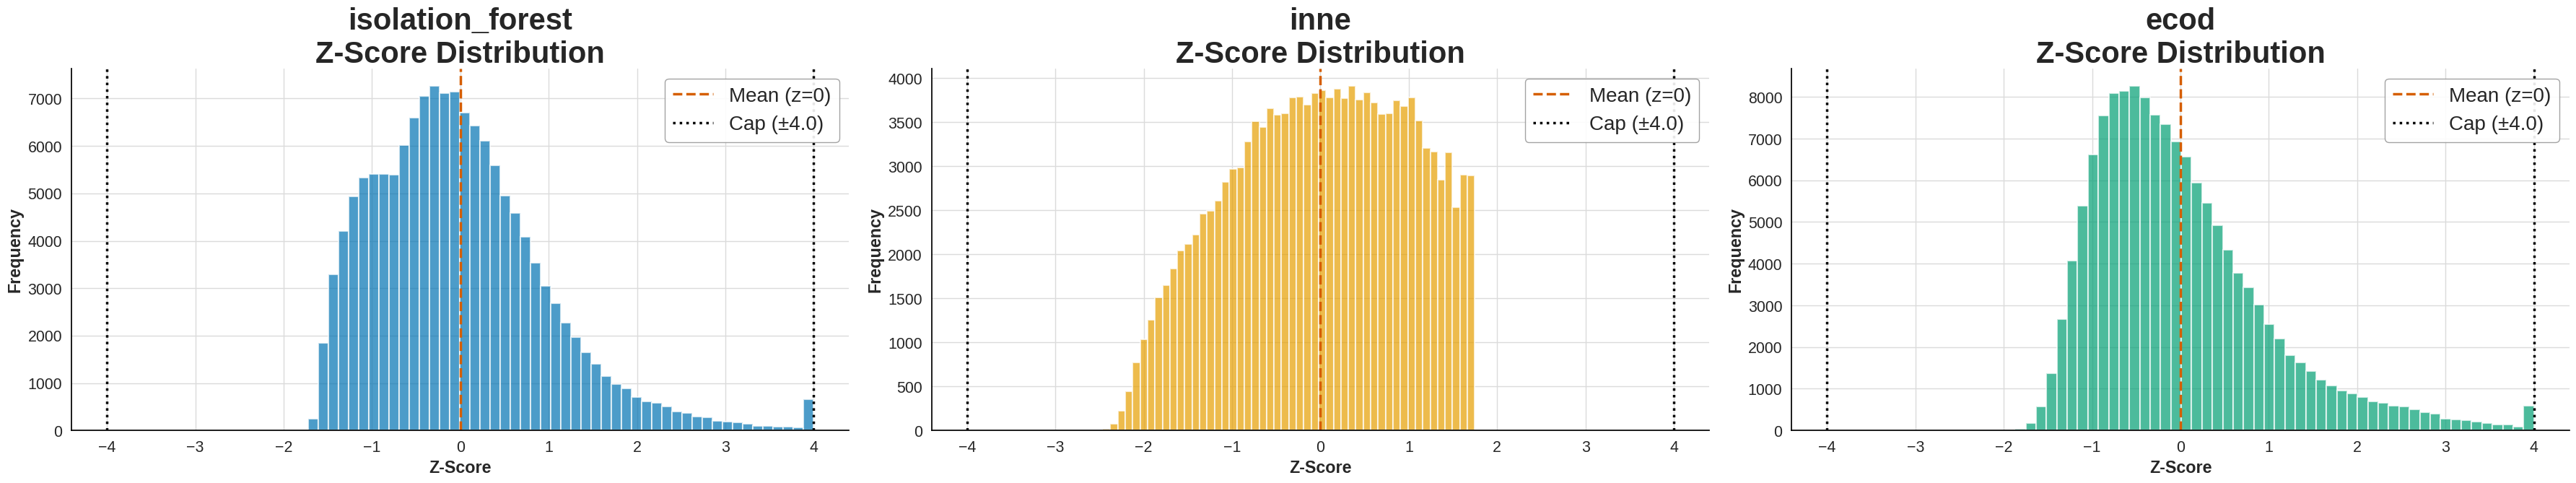

In [9]:
colors = get_colors(len(z_scores))
fig, axes = plt.subplots(1, len(z_scores), figsize=(12 * len(z_scores), 7))
if len(z_scores) == 1: axes = [axes]

for i, (model_name, z) in enumerate(z_scores.items()):
    axes[i].hist(z, bins=50, alpha=0.7, color=colors[i], edgecolor='white', linewidth=1.5)
    axes[i].axvline(x=0, color='#D55E00', linestyle='--', linewidth=2.5, label='Mean (z=0)')
    if ZSCORE_CAP:
        axes[i].axvline(x=ZSCORE_CAP, color='#000000', linestyle=':', linewidth=2.5, label=f'Cap (±{ZSCORE_CAP})')
        axes[i].axvline(x=-ZSCORE_CAP, color='#000000', linestyle=':', linewidth=2.5)
    axes[i].set_xlabel('Z-Score')
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'{model_name}\nZ-Score Distribution')
    add_legend(axes[i])

finalize(fig)
plt.savefig(f'{OUTPUT_DIR}/zscore_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


## Aggregate into Final Risk Score

In [10]:
def aggregate_scores(z_scores_dict, weights):
    total_weight = sum(weights[m] for m in z_scores_dict.keys())
    weighted_sum = np.zeros(len(list(z_scores_dict.values())[0]))
    for model_name, z in z_scores_dict.items():
        weighted_sum += weights[model_name] * z
    return weighted_sum / total_weight

def scale_to_risk_score(aggregated_z, min_score=0, max_score=100):
    z_min, z_max = aggregated_z.min(), aggregated_z.max()
    if z_max == z_min:
        return np.full_like(aggregated_z, (min_score + max_score) / 2)
    return (aggregated_z - z_min) / (z_max - z_min) * (max_score - min_score) + min_score

aggregated_z = aggregate_scores(z_scores, MODEL_WEIGHTS)
risk_scores = scale_to_risk_score(aggregated_z)

print("Final Risk Score Statistics (Min-Max Scaled):")
print("="*50)
print(f"Mean:           {risk_scores.mean():.2f}")
print(f"Std:            {risk_scores.std():.2f}")
print(f"Min:            {risk_scores.min():.2f}")
print(f"Median:         {np.median(risk_scores):.2f}")
print(f"95th Percentile:{np.percentile(risk_scores, 95):.2f}")
print(f"99th Percentile:{np.percentile(risk_scores, 99):.2f}")
print(f"Max:            {risk_scores.max():.2f}")
print("="*50)

# Anomaly threshold
threshold = np.percentile(risk_scores, (1 - FINAL_CONTAMINATION) * 100)
is_anomaly = (risk_scores >= threshold).astype(int)

print(f"\nAnomaly Threshold (top {FINAL_CONTAMINATION*100:.1f}%): {threshold:.2f}")
print(f"Number of anomalies: {is_anomaly.sum()} ({is_anomaly.sum()/len(is_anomaly)*100:.2f}%)")


Final Risk Score Statistics (Min-Max Scaled):
Mean:           37.40
Std:            17.07
Min:            0.00
Median:         35.78
95th Percentile:68.37
99th Percentile:85.87
Max:            100.00

Anomaly Threshold (top 5.0%): 68.37
Number of anomalies: 7042 (5.00%)


## Risk Categories: Low, Medium, High, Critical

In [11]:
# Build risk categories: Low, Medium, High, Critical (above threshold)
# Critical is anything >= threshold (top 5%)
# Below threshold: split into Low (0-25), Medium (25-50), High (50-threshold)
risk_category = np.full(len(risk_scores), 'Low', dtype=object)
risk_category[risk_scores >= 25] = 'Medium'
risk_category[risk_scores >= 50] = 'High'
risk_category[risk_scores >= threshold] = 'Critical'

# Sub-categories within Critical
is_critical = (risk_category == 'Critical')

# Step 1: Critical + Active Medicaid Provider → Critical-AMP
if active_medicaid is not None:
    critical_amp_mask = is_critical & (active_medicaid == 1)
    risk_category[critical_amp_mask] = 'Critical-AMP'
    print(f"Critical-AMP (Critical + Active Medicaid): {critical_amp_mask.sum():,}")
else:
    critical_amp_mask = np.zeros(len(risk_category), dtype=bool)

# Step 2: Remaining Critical + Missouri → Critical-MO
if provider_state is not None:
    still_critical = (risk_category == 'Critical')
    critical_mo_mask = still_critical & (provider_state == 'MO')
    risk_category[critical_mo_mask] = 'Critical-MO'
    print(f"Critical-MO  (Critical + Missouri, non-AMP): {critical_mo_mask.sum():,}")
else:
    critical_mo_mask = np.zeros(len(risk_category), dtype=bool)

print(f"Critical     (remaining): {(risk_category == 'Critical').sum():,}")

# Summary
for cat in ['Low', 'Medium', 'High', 'Critical', 'Critical-AMP', 'Critical-MO']:
    n = (risk_category == cat).sum()
    if n > 0:
        print(f"  {cat}: {n:,} ({n/len(risk_category)*100:.2f}%)")


Critical-AMP (Critical + Active Medicaid): 1,177
Critical-MO  (Critical + Missouri, non-AMP): 129
Critical     (remaining): 5,736
  Low: 36,075 (25.62%)
  Medium: 74,613 (52.98%)
  High: 23,097 (16.40%)
  Critical: 5,736 (4.07%)
  Critical-AMP: 1,177 (0.84%)
  Critical-MO: 129 (0.09%)


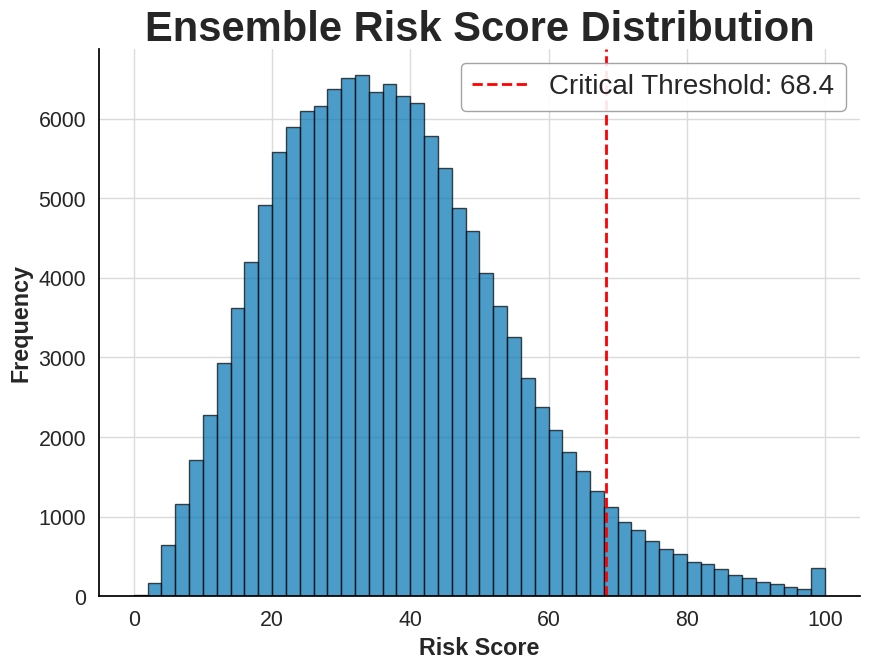

In [12]:
# Create a new standalone figure for histogram
fig, ax = plt.subplots(figsize=(9, 7))  # initialize single-axis figure

# Plot histogram of risk scores
ax.hist(risk_scores, bins=50, alpha=0.7, color='#0072B2', edgecolor='black')  # draw histogram

# Add vertical threshold line
ax.axvline(x=threshold, color='red', linestyle='--', linewidth=2,
           label=f'Critical Threshold: {threshold:.1f}')  # add threshold marker

# Set axis labels
ax.set_xlabel('Risk Score')  # label x-axis
ax.set_ylabel('Frequency')  # label y-axis

# Set title
ax.set_title('Ensemble Risk Score Distribution')  # title for histogram

# Add legend
add_legend(ax)  # attach legend

# Finalize layout
finalize(fig)  # apply formatting

# Save figure
plt.savefig(f'{OUTPUT_DIR}/risk_score_distribution_hist.png', dpi=150, bbox_inches='tight')  # export image

# Show plot
plt.show()  # render plot

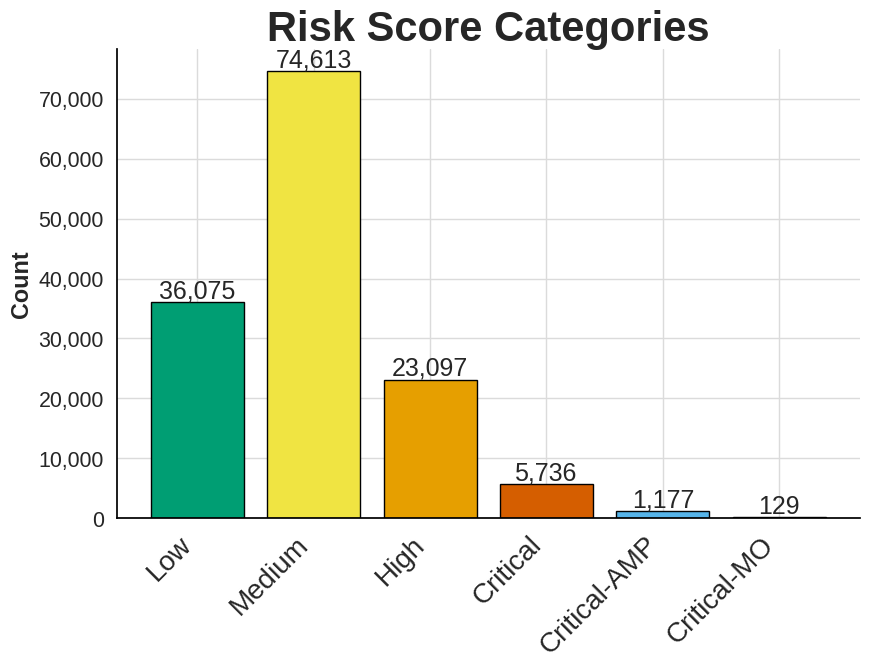

In [64]:
# Create a new standalone figure for bar chart
fig, ax = plt.subplots(figsize=(9, 7))  # initialize single-axis figure

# Define category ordering
cat_order = ['Low', 'Medium', 'High', 'Critical', 'Critical-AMP', 'Critical-MO']  # desired order

# Convert to ordered categorical
category_series = pd.Categorical(risk_category, categories=cat_order, ordered=True)  # enforce order

# Compute category counts aligned to order
category_counts = pd.Series(category_series).value_counts().reindex(cat_order).fillna(0).astype(int)  # compute counts

# Remove zero-count categories
category_counts = category_counts[category_counts > 0]  # filter empty categories

# Define color mapping
colors_risk = {
    'Low': '#009E73', 'Medium': '#F0E442', 'High': '#E69F00',
    'Critical': '#D55E00', 'Critical-AMP': '#56B4E9', 'Critical-MO': '#0072B2'
}  # color palette

# Map colors to categories
bar_colors = [colors_risk[cat] for cat in category_counts.index]  # assign colors

# Plot bar chart
ax.bar(range(len(category_counts)), category_counts.values,
       color=bar_colors, edgecolor='black')  # draw bars

# Set x-axis ticks
ax.set_xticks(range(len(category_counts)))  # set tick positions

# Set x-axis labels
ax.set_xticklabels(category_counts.index, rotation=45, ha='right', fontsize=20) 

# Set y-axis label
ax.set_ylabel('Count')  # label y-axis

# Set title
ax.set_title('Risk Score Categories')  # title for bar chart

import matplotlib.ticker as mticker  # import ticker utilities

# Apply thousands separator formatter
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))  # format with commas

# Annotate bars
for i, v in enumerate(category_counts.values):  # iterate through bars
    ax.text(i, v + max(category_counts.values)*0.01, f'{v:,}', ha='center', fontsize=FONT_SIZE_ANNOT-2)  # add labels

# Finalize layout
finalize(fig)  # apply formatting

# Save figure
plt.savefig(f'{OUTPUT_DIR}/risk_score_categories.png', dpi=150, bbox_inches='tight')  # export image

# Show plot
plt.show()  # render plot

## Model Contribution Analysis

In [14]:
contribution_df = pd.DataFrame({
    f'{model}_zscore': z for model, z in z_scores.items()
})
contribution_df['aggregated_z'] = aggregated_z
contribution_df['risk_score'] = risk_scores
contribution_df['is_anomaly'] = is_anomaly

print("Model Contribution Analysis for Detected Anomalies:")
print("="*60)
for model_name in z_scores.keys():
    zscore_col = f'{model_name}_zscore'
    anomaly_mean = contribution_df[contribution_df['is_anomaly'] == 1][zscore_col].mean()
    normal_mean = contribution_df[contribution_df['is_anomaly'] == 0][zscore_col].mean()
    print(f"{model_name}:")
    print(f"  Anomaly mean z: {anomaly_mean:.4f}  |  Normal mean z: {normal_mean:.4f}  |  Diff: {anomaly_mean - normal_mean:.4f}")


Model Contribution Analysis for Detected Anomalies:
isolation_forest:
  Anomaly mean z: 2.4023  |  Normal mean z: -0.1308  |  Diff: 2.5331
inne:
  Anomaly mean z: 1.4873  |  Normal mean z: -0.0794  |  Diff: 1.5667
ecod:
  Anomaly mean z: 2.5540  |  Normal mean z: -0.1370  |  Diff: 2.6909


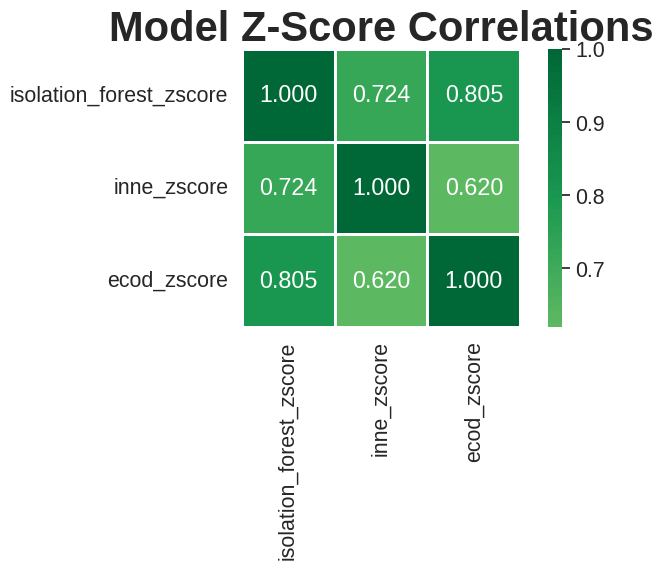


Low correlation = models capture different anomaly types (good for ensemble)


In [15]:
model_names = list(z_scores.keys())
zscore_cols = [f'{m}_zscore' for m in model_names]

corr_matrix = contribution_df[zscore_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0,
            fmt='.3f', square=True, linewidths=1)
plt.title('Model Z-Score Correlations')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/model_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLow correlation = models capture different anomaly types (good for ensemble)")


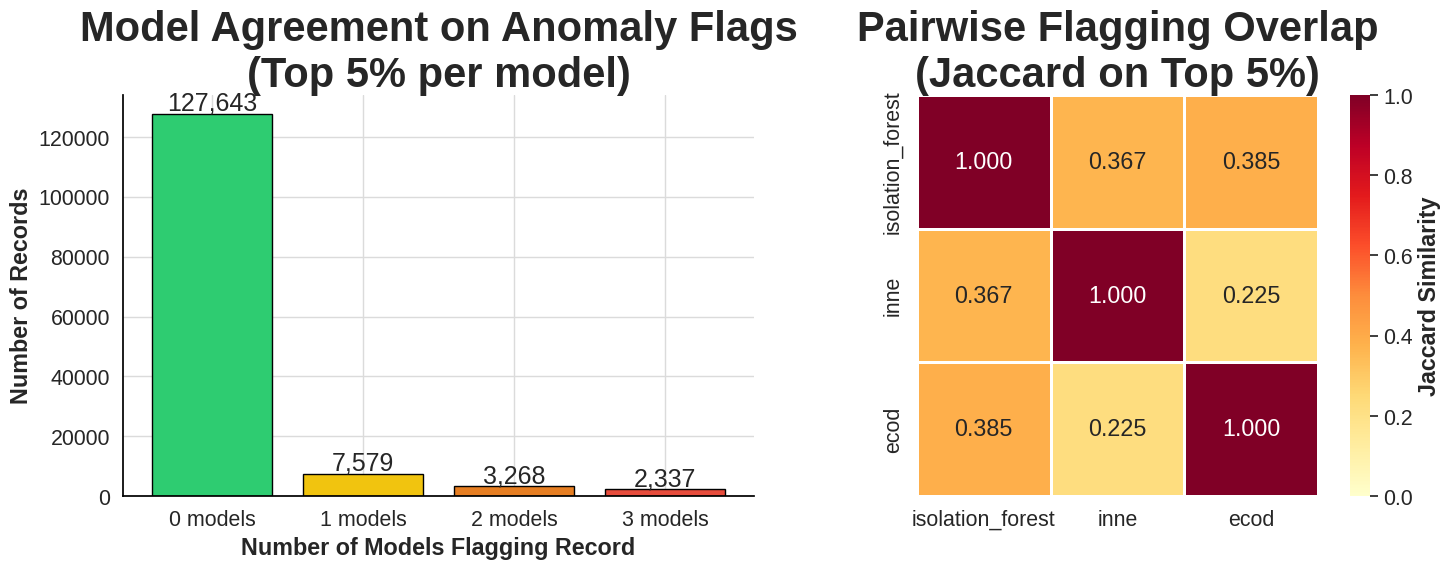


MODEL AGREEMENT SUMMARY
  Flagged by 0 models:  127,643 records (90.64%)
  Flagged by 1 models:    7,579 records (5.38%)
  Flagged by 2 models:    3,268 records (2.32%)
  Flagged by 3 models:    2,337 records (1.66%)

  Full consensus (all 3 models): 2,337 — highest-confidence anomalies


In [16]:
# Model Agreement: How often do models agree on who is anomalous?
for m in model_names:
    col = f'{m}_zscore'
    cutoff = np.percentile(contribution_df[col], 95)
    contribution_df[f'{m}_flag'] = (contribution_df[col] >= cutoff).astype(int)

flag_cols = [f'{m}_flag' for m in model_names]
contribution_df['n_models_flagged'] = contribution_df[flag_cols].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Agreement counts
agreement_counts = contribution_df['n_models_flagged'].value_counts().sort_index()
colors_agree = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
bars = axes[0].bar(agreement_counts.index, agreement_counts.values,
                   color=[colors_agree[i] for i in agreement_counts.index], edgecolor='black')
axes[0].set_xlabel('Number of Models Flagging Record')
axes[0].set_ylabel('Number of Records')
axes[0].set_title('Model Agreement on Anomaly Flags\n(Top 5% per model)')
axes[0].set_xticks(range(len(model_names)+1))
axes[0].set_xticklabels([f'{i} models' for i in range(len(model_names)+1)])
for bar, v in zip(bars, agreement_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + max(agreement_counts.values)*0.01,
                 f'{v:,}', ha='center', fontsize=FONT_SIZE_ANNOT-2)

# Jaccard heatmap
n_models = len(model_names)
jaccard_matrix = np.ones((n_models, n_models))
for i in range(n_models):
    for j in range(n_models):
        if i != j:
            set_i = set(contribution_df[contribution_df[f'{model_names[i]}_flag'] == 1].index)
            set_j = set(contribution_df[contribution_df[f'{model_names[j]}_flag'] == 1].index)
            intersection = len(set_i & set_j)
            union = len(set_i | set_j)
            jaccard_matrix[i, j] = intersection / union if union > 0 else 0

sns.heatmap(jaccard_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=model_names, yticklabels=model_names,
            square=True, linewidths=1, ax=axes[1], vmin=0, vmax=1,
            cbar_kws={'label': 'Jaccard Similarity'})
axes[1].set_title('Pairwise Flagging Overlap\n(Jaccard on Top 5%)')

finalize(fig)
plt.savefig(f'{OUTPUT_DIR}/model_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMODEL AGREEMENT SUMMARY")
print("=" * 60)
for n in range(len(model_names)+1):
    count = (contribution_df['n_models_flagged'] == n).sum()
    pct = count / len(contribution_df) * 100
    print(f"  Flagged by {n} models: {count:>8,} records ({pct:.2f}%)")

consensus = (contribution_df['n_models_flagged'] == len(model_names)).sum()
print(f"\n  Full consensus (all {len(model_names)} models): {consensus:,} — highest-confidence anomalies")


## Ensemble Feature Importance (Model-Specific Decompositions)

**Methodology**: Model-specific decompositions — DIFFI for Isolation Forest (Carletti et al., 2023), tail-probability decomposition for ECOD, perturbation-based contributions for iNNE — weight-averaged to produce signed global feature importance with directionality.

For each feature, shuffle its values across the dataset, re-score through all 3 models,
and measure the drop in the ensemble anomaly score. Features whose shuffling causes the
largest drop are most important to the ensemble's ability to detect anomalies.

This replaces the previous weighted rank fusion approach with a direct measurement of
each feature's contribution to the actual ensemble scoring function.



In [17]:
# ============================================================================
# GLOBAL FEATURE IMPORTANCE VIA MODEL-SPECIFIC DECOMPOSITIONS
# ============================================================================
# Instead of permutation importance (which loses directionality), we compute
# signed per-feature contribution matrices from each model's native structure:
#   - Isolation Forest: DIFFI (Carletti et al., 2023, Eng. Appl. of AI)
#   - ECOD: Exact tail-probability decomposition (inherent to ECOD's design)
#   - iNNE: Perturbation-based marginal contributions
# Then weight-average across models (mirroring ensemble aggregation) and
# take the mean across all records for global importance with direction.
# ============================================================================

import time
from scipy import sparse

# ── Helper: find training data in a PyOD model ───────────────────────────────
def _find_pyod_train_data(model, n_features):
    """Search common PyOD attribute names for the training data matrix."""
    for attr in ['X_train_', 'train_data_', 'X_train']:
        val = getattr(model, attr, None)
        if val is not None:
            return val
    for attr in dir(model):
        if attr.startswith('__'):
            continue
        val = getattr(model, attr, None)
        try:
            if hasattr(val, 'shape') and val.ndim == 2 and val.shape[1] == n_features:
                print(f'  Found training data in model attribute: {attr} {val.shape}')
                return val
        except Exception:
            continue
    return None

# ── 1. ECOD: vectorized exact decomposition ─────────────────────────────────
def ecod_contribution_matrix(model, scaler, X_input, feature_cols):
    """Return (n_samples, n_features) matrix of per-feature anomaly contributions."""
    X_scaled = scaler.transform(X_input)
    n_samples, n_features = X_scaled.shape
    X_train = _find_pyod_train_data(model, n_features)
    if X_train is not None:
        scores = np.zeros((n_samples, n_features))
        for j in range(n_features):
            sorted_train = np.sort(X_train[:, j])
            n_train = len(sorted_train)
            left_rank  = np.searchsorted(sorted_train, X_scaled[:, j], side='right')
            left_prob   = np.clip(left_rank / n_train, 1e-10, 1.0)
            right_rank = n_train - np.searchsorted(sorted_train, X_scaled[:, j], side='left')
            right_prob  = np.clip(right_rank / n_train, 1e-10, 1.0)
            scores[:, j] = np.maximum(-np.log(left_prob), -np.log(right_prob))
        return scores
    else:
        print('  ECOD: training data not found — falling back to perturbation method')
        return perturbation_contribution_matrix(model, scaler, X_input, feature_cols, 'ecod')

print('Computing ECOD contribution matrix...')
t0 = time.time()
ecod_contrib = ecod_contribution_matrix(models['ecod'], scalers['ecod'], X, feature_cols)
print(f'  Done in {time.time()-t0:.1f}s — shape: {ecod_contrib.shape}')

# ── 2. Isolation Forest: Sparse-vectorized DIFFI ────────────────────────────
def iforest_contribution_matrix(model, scaler, X_input, feature_cols):
    """Sparse-vectorized DIFFI: for each tree, build a weight vector over
    internal nodes, then use sparse node_indicator @ weight_by_feature to
    accumulate contributions in one shot per tree — no Python loops over
    nodes or features.
    Ref: Carletti, Terzi & Susto (2023), Eng. Appl. of AI, 119, 105730."""
    X_scaled = scaler.transform(X_input)
    n_samples, n_features = X_scaled.shape
    contributions = np.zeros((n_samples, n_features))
    n_trees = len(model.estimators_)

    for t_idx, tree_model in enumerate(model.estimators_):
        if t_idx % 25 == 0:
            print(f'    Tree {t_idx+1}/{n_trees}...', end='\r')
        tree = tree_model.tree_
        n_nodes = tree.node_count
        children_left = tree.children_left
        children_right = tree.children_right
        node_features = tree.feature

        is_internal = children_left != children_right

        depths = np.zeros(n_nodes, dtype=np.int32)
        stack = [(0, 0)]
        while stack:
            nid, d = stack.pop()
            depths[nid] = d
            if children_left[nid] != children_right[nid]:
                stack.append((children_left[nid], d + 1))
                stack.append((children_right[nid], d + 1))

        internal_idx = np.where(is_internal)[0]
        if len(internal_idx) == 0:
            continue
        node_weights = 1.0 / (depths[internal_idx] + 1)
        node_feats = node_features[internal_idx]

        W = sparse.csc_matrix(
            (node_weights, (internal_idx, node_feats)),
            shape=(n_nodes, n_features)
        )

        node_indicator = tree_model.decision_path(X_scaled)
        tree_contrib = node_indicator @ W
        # Ensure dense before accumulating
        if sparse.issparse(tree_contrib):
            tree_contrib = tree_contrib.toarray()
        elif isinstance(tree_contrib, np.matrix):
            tree_contrib = np.asarray(tree_contrib)
        contributions += tree_contrib

    contributions /= n_trees
    print(f'    Done — {n_trees} trees processed.' + ' ' * 20)
    return contributions

print('\nComputing Isolation Forest (DIFFI) contribution matrix...')
t0 = time.time()
iforest_contrib = iforest_contribution_matrix(
    models['isolation_forest'], scalers['isolation_forest'], X, feature_cols)
print(f'  Done in {time.time()-t0:.1f}s — shape: {iforest_contrib.shape}')

# ── 3. iNNE: perturbation-based contributions ─────────────────────────────
def perturbation_contribution_matrix(model, scaler, X_input, feature_cols, model_name):
    """Signed perturbation contributions: score_original - score_with_feature_at_median."""
    X_scaled = scaler.transform(X_input)
    n_samples, n_features = X_scaled.shape
    if model_name == 'isolation_forest':
        original_scores = -model.decision_function(X_scaled)
    else:
        original_scores = model.decision_function(X_scaled)
    reference_values = np.median(X_scaled, axis=0)
    contributions = np.zeros((n_samples, n_features))
    for j in range(n_features):
        if j % 10 == 0:
            print(f'    Feature {j+1}/{n_features}...', end='\r')
        X_pert = X_scaled.copy()
        X_pert[:, j] = reference_values[j]
        if model_name == 'isolation_forest':
            pert_scores = -model.decision_function(X_pert)
        else:
            pert_scores = model.decision_function(X_pert)
        contributions[:, j] = original_scores - pert_scores
    print(f'    Done — {n_features} features.' + ' ' * 20)
    return contributions

print('\nComputing iNNE perturbation contribution matrix...')
t0 = time.time()
inne_contrib = perturbation_contribution_matrix(
    models['inne'], scalers['inne'], X, feature_cols, 'inne')
print(f'  Done in {time.time()-t0:.1f}s — shape: {inne_contrib.shape}')

# ── 4. Weight-average across models (mirrors ensemble aggregation) ────────
contrib_per_model = {
    'isolation_forest': iforest_contrib,
    'ecod': ecod_contrib,
    'inne': inne_contrib
}

total_weight = sum(MODEL_WEIGHTS[m] for m in contrib_per_model)
ensemble_contrib = np.zeros_like(iforest_contrib)
for m, c in contrib_per_model.items():
    ensemble_contrib += (MODEL_WEIGHTS[m] / total_weight) * c

# ── 5. Global importance = mean signed contribution per feature ────────────
mean_contrib = ensemble_contrib.mean(axis=0)
mean_abs_contrib = np.abs(ensemble_contrib).mean(axis=0)

# Flatten in case of residual 2D shape from sparse operations
mean_contrib = np.asarray(mean_contrib).ravel()
mean_abs_contrib = np.asarray(mean_abs_contrib).ravel()

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': mean_abs_contrib,
    'direction': mean_contrib
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('\nENSEMBLE FEATURE IMPORTANCE — Model-Specific Decompositions (Top 20)')
print('=' * 75)
print(f"{'Rank':<6} {'Feature':<40} {'|Importance|':>12} {'Direction':>12}")
print('-' * 75)
for i, row in importance_df.head(20).iterrows():
    arrow = '\u2191 anomaly' if row['direction'] > 0 else '\u2193 anomaly'
    print(f"{i+1:<6} {row['feature']:<40} {row['importance']:>12.4f} {row['direction']:>+10.4f} {arrow}")
print('\nDirection: + means higher feature values push the anomaly score UP')
print('           - means higher feature values push the anomaly score DOWN')

Computing ECOD contribution matrix...
  Done in 2.0s — shape: (140827, 63)

Computing Isolation Forest (DIFFI) contribution matrix...
    Done — 100 trees processed.                    
  Done in 8.6s — shape: (140827, 63)

Computing iNNE perturbation contribution matrix...
    Done — 63 features.                    
  Done in 460.7s — shape: (140827, 63)

ENSEMBLE FEATURE IMPORTANCE — Model-Specific Decompositions (Top 20)
Rank   Feature                                  |Importance|    Direction
---------------------------------------------------------------------------
1      avg_suplr_sbmtd_chrg_mean_zscore_by_type       0.5924    +0.5924 ↑ anomaly
2      submitted_to_standardized_ratio_pctile_by_type       0.5906    +0.5906 ↑ anomaly
3      avg_suplr_sbmtd_chrg_max_pctile_by_type        0.5856    +0.5856 ↑ anomaly
4      avg_suplr_sbmtd_chrg_mean_pctile_by_type       0.5843    +0.5843 ↑ anomaly
5      avg_suplr_mdcr_pymt_amt_sum                    0.5830    +0.5830 ↑ anomaly
6     

### Grouped Bar Chart: Critical vs All Scored — Top 10 Feature Importances

Critical subset: 7,042 records


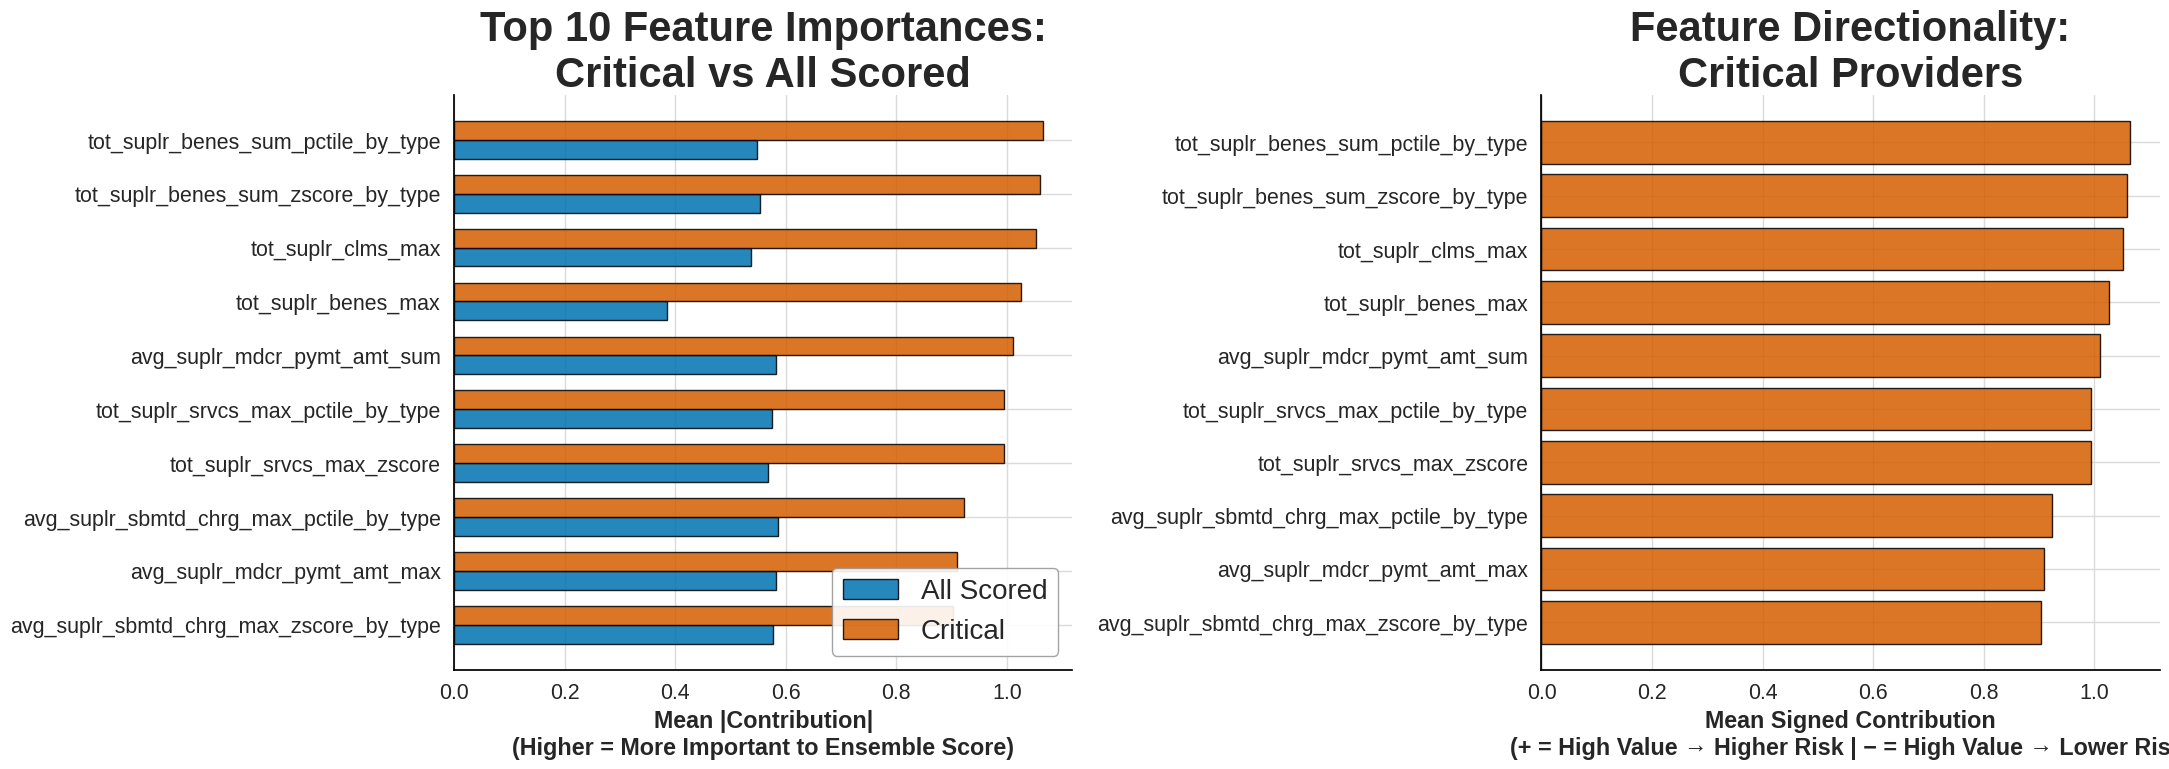


PER-MODEL BREAKDOWN — Critical Providers, Top 10 Features
Feature                               IF (DIFFI)         ECOD         iNNE     Ensemble
------------------------------------------------------------------------------------------
tot_suplr_benes_sum_pctile_by_type       +0.0593      +3.1380      -0.0020      +1.0651
tot_suplr_benes_sum_zscore_by_type       +0.0351      +3.1453      -0.0026      +1.0593
tot_suplr_clms_max                       +0.0414      +3.1170      -0.0018      +1.0522
tot_suplr_benes_max                      +0.0455      +3.0360      -0.0020      +1.0265
avg_suplr_mdcr_pymt_amt_sum              +0.0610      +2.9734      -0.0017      +1.0109
tot_suplr_srvcs_max_pctile_by_type       +0.0745      +2.9116      -0.0018      +0.9948
tot_suplr_srvcs_max_zscore               +0.0854      +2.8960      +0.0027      +0.9947
avg_suplr_sbmtd_chrg_max_pctile_by_type      +0.0668      +2.7031      -0.0010      +0.9230
avg_suplr_mdcr_pymt_amt_max              +0.0616      

In [18]:
# ── Feature importance: Critical subset vs All Scored ─────────────────────
critical_mask = np.isin(risk_category, ['Critical', 'Critical-AMP', 'Critical-MO'])
critical_indices = np.where(critical_mask)[0]

print(f'Critical subset: {critical_mask.sum():,} records')

# Slice the pre-computed ensemble contribution matrix
critical_contrib = ensemble_contrib[critical_indices]
mean_abs_critical = np.abs(critical_contrib).mean(axis=0)
mean_dir_critical = critical_contrib.mean(axis=0)

importance_critical_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_critical': mean_abs_critical,
    'direction_critical': mean_dir_critical
}).sort_values('importance_critical', ascending=False).reset_index(drop=True)

# Merge for grouped bar chart
merged_imp = importance_df.rename(columns={'importance': 'All Scored'}).merge(
    importance_critical_df.rename(columns={'importance_critical': 'Critical'}),
    on='feature'
)

# Top 10 by Critical importance
top10_critical = merged_imp.sort_values('Critical', ascending=False).head(10)

# ── Grouped bar chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Left: magnitude comparison
x = np.arange(len(top10_critical))
bar_width = 0.35
axes[0].barh(x + bar_width/2, top10_critical['All Scored'].values, bar_width,
             color='#0072B2', edgecolor='black', label='All Scored', alpha=0.85)
axes[0].barh(x - bar_width/2, top10_critical['Critical'].values, bar_width,
             color='#D55E00', edgecolor='black', label='Critical', alpha=0.85)
axes[0].set_yticks(x)
axes[0].set_yticklabels(top10_critical['feature'].values)
axes[0].set_xlabel('Mean |Contribution|\n(Higher = More Important to Ensemble Score)')
axes[0].set_title('Top 10 Feature Importances:\nCritical vs All Scored')
axes[0].invert_yaxis()
add_legend(axes[0], loc='lower right')

# Right: directionality for Critical providers
top10_dir = merged_imp.sort_values('Critical', ascending=False).head(10)
dir_vals = top10_dir['direction_critical'].values
bar_colors = ['#D55E00' if v > 0 else '#0072B2' for v in dir_vals]
axes[1].barh(range(len(top10_dir)), dir_vals, color=bar_colors, edgecolor='black', alpha=0.85)
axes[1].set_yticks(range(len(top10_dir)))
axes[1].set_yticklabels(top10_dir['feature'].values)
axes[1].set_xlabel('Mean Signed Contribution\n(+ = High Value → Higher Risk | − = High Value → Lower Risk)')
axes[1].set_title('Feature Directionality:\nCritical Providers')
axes[1].invert_yaxis()
axes[1].axvline(x=0, color='black', linewidth=1, alpha=0.5)

finalize(fig)
plt.savefig(f'{OUTPUT_DIR}/ensemble_feature_importance_grouped.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-model breakdown for Critical providers ────────────────────────────
print('\nPER-MODEL BREAKDOWN — Critical Providers, Top 10 Features')
print('=' * 90)
print(f"{'Feature':<35} {'IF (DIFFI)':>12} {'ECOD':>12} {'iNNE':>12} {'Ensemble':>12}")
print('-' * 90)
for _, row in top10_critical.iterrows():
    feat = row['feature']
    j = feature_cols.index(feat)
    if_val  = iforest_contrib[critical_indices, j].mean()
    ec_val  = ecod_contrib[critical_indices, j].mean()
    inn_val = inne_contrib[critical_indices, j].mean()
    ens_val = ensemble_contrib[critical_indices, j].mean()
    print(f"{feat:<35} {if_val:>+12.4f} {ec_val:>+12.4f} {inn_val:>+12.4f} {ens_val:>+12.4f}")

# Print comparison table
print('\nTOP 10 FEATURE IMPORTANCE COMPARISON')
print('=' * 70)
print(f"{'Rank':<6} {'Feature':<40} {'All Scored':>12} {'Critical':>12}")
print('-' * 70)
for i, (_, row) in enumerate(top10_critical.iterrows(), 1):
    print(f"{i:<6} {row['feature']:<40} {row['All Scored']:>12.4f} {row['Critical']:>12.4f}")


## Per-Instance Feature Explainability (Critical-AMP & Critical-MO)

Computes **NPI-specific** top-5 feature contributions for each model.
Only computed for **Critical-AMP** and **Critical-MO** providers.

| Model | Method | Reference |
|-------|--------|-----------|
| **ECOD** | Native per-feature tail-probability decomposition | Li et al. (2022) |
| **Isolation Forest** | Decision-path split-feature accumulation (depth-weighted) | Carletti et al. (2019) — DIFFI |
| **INNE** | Perturbation-based leave-one-out | Ribeiro et al. (2016) |


In [19]:
TOP_K = 5

def _extract_topk_from_matrix(contributions, feature_cols, top_k, model_name):
    """Extract top-k features per row from an (n_samples, n_features) contribution matrix."""
    n_samples = contributions.shape[0]
    k = min(top_k, contributions.shape[1])
    top_indices = np.argsort(-contributions, axis=1)[:, :k]
    result = {}
    for rank in range(k):
        result[f'{model_name}_top{rank+1}_feature'] = [
            feature_cols[top_indices[i, rank]] for i in range(n_samples)]
        result[f'{model_name}_top{rank+1}_contribution'] = [
            round(float(contributions[i, top_indices[i, rank]]), 4) for i in range(n_samples)]
    return pd.DataFrame(result)


def ecod_instance_features(model, scaler, X_subset, feature_cols, top_k=5):
    """ECOD per-feature decomposition via tail probabilities (exact)."""
    X_scaled = scaler.transform(X_subset)
    n_samples, n_features = X_scaled.shape
    per_feature_scores = np.zeros((n_samples, n_features))
    X_train = getattr(model, 'X_train_', getattr(model, 'train_data_', None))
    if X_train is not None:
        for j in range(n_features):
            sorted_train = np.sort(X_train[:, j])
            n_train = len(sorted_train)
            left_rank = np.searchsorted(sorted_train, X_scaled[:, j], side='right')
            left_prob = np.clip(left_rank / n_train, 1e-10, 1.0)
            right_rank = n_train - np.searchsorted(sorted_train, X_scaled[:, j], side='left')
            right_prob = np.clip(right_rank / n_train, 1e-10, 1.0)
            per_feature_scores[:, j] = np.maximum(-np.log(left_prob), -np.log(right_prob))
    else:
        print('  ECOD: X_train_ not found, falling back to perturbation method')
        return perturbation_features(model, scaler, X_subset, feature_cols, 'ecod', top_k)
    return _extract_topk_from_matrix(per_feature_scores, feature_cols, top_k, 'ecod')


def iforest_instance_features(model, scaler, X_subset, feature_cols, top_k=5):
    """Isolation Forest: Sparse-vectorized DIFFI for a subset of instances.
    Same sparse matmul approach as the global version — no sample-level loops."""
    from scipy import sparse
    X_scaled = scaler.transform(X_subset)
    n_samples, n_features = X_scaled.shape
    contributions = np.zeros((n_samples, n_features))

    for tree_model in model.estimators_:
        tree = tree_model.tree_
        n_nodes = tree.node_count
        children_left = tree.children_left
        children_right = tree.children_right
        node_features = tree.feature
        is_internal = children_left != children_right

        # Compute depths
        depths = np.zeros(n_nodes, dtype=np.int32)
        stack = [(0, 0)]
        while stack:
            nid, d = stack.pop()
            depths[nid] = d
            if children_left[nid] != children_right[nid]:
                stack.append((children_left[nid], d + 1))
                stack.append((children_right[nid], d + 1))

        internal_idx = np.where(is_internal)[0]
        if len(internal_idx) == 0:
            continue
        node_weights = 1.0 / (depths[internal_idx] + 1)
        node_feats = node_features[internal_idx]

        W = sparse.csc_matrix(
            (node_weights, (internal_idx, node_feats)),
            shape=(n_nodes, n_features)
        )
        node_indicator = tree_model.decision_path(X_scaled)
        contributions += (node_indicator @ W)

    contributions /= len(model.estimators_)
    if sparse.issparse(contributions):
        contributions = contributions.toarray()
    return _extract_topk_from_matrix(contributions, feature_cols, top_k, 'isolation_forest')


def perturbation_features(model, scaler, X_subset, feature_cols, model_name, top_k=5):
    """Model-agnostic perturbation-based feature contributions."""
    X_scaled = scaler.transform(X_subset)
    n_samples, n_features = X_scaled.shape
    if model_name == 'isolation_forest':
        original_scores = -model.decision_function(X_scaled)
    else:
        original_scores = model.decision_function(X_scaled)
    reference_values = np.median(X_scaled, axis=0)
    feature_contributions = np.zeros((n_samples, n_features))
    for j in range(n_features):
        if j % 20 == 0:
            print(f'    Feature {j+1}/{n_features}...', end='\r')
        X_perturbed = X_scaled.copy()
        X_perturbed[:, j] = reference_values[j]
        if model_name == 'isolation_forest':
            perturbed_scores = -model.decision_function(X_perturbed)
        else:
            perturbed_scores = model.decision_function(X_perturbed)
        feature_contributions[:, j] = original_scores - perturbed_scores
    print(f'    Done — {n_features} features perturbed' + ' ' * 20)
    return _extract_topk_from_matrix(feature_contributions, feature_cols, top_k, model_name)


def compute_instance_features_for_subset(subset_indices, subset_label, X, feature_cols,
                                          models, scalers, top_k):
    """Compute per-instance top-k features for a given subset."""
    X_subset = X.iloc[subset_indices]
    print(f"\n{'─'*70}")
    print(f"{subset_label}: {len(subset_indices):,} providers to explain")
    print(f"{'─'*70}")
    dfs = []
    for model_name in models.keys():
        print(f'  {model_name}...')
        m, s = models[model_name], scalers[model_name]
        if model_name == 'ecod':
            feat_df = ecod_instance_features(m, s, X_subset, feature_cols, top_k)
        elif model_name == 'isolation_forest':
            feat_df = iforest_instance_features(m, s, X_subset, feature_cols, top_k)
        else:
            feat_df = perturbation_features(m, s, X_subset, feature_cols, model_name, top_k)
        dfs.append(feat_df)
    combined = pd.concat(dfs, axis=1)
    combined.index = subset_indices
    return combined


In [20]:
# Identify Critical-AMP and Critical-MO subsets
critical_amp_indices = np.where(risk_category == 'Critical-AMP')[0]
critical_mo_indices = np.where(risk_category == 'Critical-MO')[0]
explain_indices = np.concatenate([critical_amp_indices, critical_mo_indices])

print(f"Per-instance explainability targets:")
print(f"  Critical-AMP: {len(critical_amp_indices):,}")
print(f"  Critical-MO:  {len(critical_mo_indices):,}")
print(f"  Total:        {len(explain_indices):,}")

instance_parts = []
if len(critical_amp_indices) > 0:
    amp_features = compute_instance_features_for_subset(
        critical_amp_indices, 'Critical-AMP', X, feature_cols, models, scalers, TOP_K)
    instance_parts.append(amp_features)
if len(critical_mo_indices) > 0:
    mo_features = compute_instance_features_for_subset(
        critical_mo_indices, 'Critical-MO', X, feature_cols, models, scalers, TOP_K)
    instance_parts.append(mo_features)

if instance_parts:
    per_instance_features_all = pd.concat(instance_parts, axis=0)
    print(f'\nCombined per-instance feature matrix: {per_instance_features_all.shape}')
    for model_name in models.keys():
        col = f'{model_name}_top1_feature'
        print(f'  {model_name} top-1 feature: {per_instance_features_all[col].nunique()} unique values')
else:
    per_instance_features_all = pd.DataFrame()
    print('No Critical-AMP or Critical-MO providers — no per-instance features computed')


Per-instance explainability targets:
  Critical-AMP: 1,177
  Critical-MO:  129
  Total:        1,306

──────────────────────────────────────────────────────────────────────
Critical-AMP: 1,177 providers to explain
──────────────────────────────────────────────────────────────────────
  isolation_forest...
  inne...
    Done — 63 features perturbed                    
  ecod...
  ECOD: X_train_ not found, falling back to perturbation method


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    1.6s remaining:    4.8s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    1.8s finished


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.1s remaining:    0.4s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.5s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.5s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.5s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Don

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.1s remaining:    0.4s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.1s remaining:    0.4s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.1s remaining:    0.4s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.5s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Don

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.5s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.5s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.5s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.5s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Don

...

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.5s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.5s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.5s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.1s remaining:    0.4s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Don

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.5s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.1s remaining:    0.4s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.1s remaining:    0.4s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.1s remaining:    0.4s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Don

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.5s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.5s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.1s remaining:    0.4s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.1s remaining:    0.4s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Don

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.5s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.5s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.5s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished


    Done — 63 features perturbed                    

Combined per-instance feature matrix: (1306, 30)
  isolation_forest top-1 feature: 12 unique values
  inne top-1 feature: 59 unique values
  ecod top-1 feature: 61 unique values


### Top Features Driving Critical-AMP & Critical-MO Scores

Aggregates per-instance feature contributions across all Critical-AMP and Critical-MO NPIs
to show which features most frequently appear as top drivers, and their average contribution
strength. This uses the same per-instance methods (ECOD decomposition, DIFFI, perturbation)
that produced each NPI's individual explanation.


In [60]:
def plot_feature_summary(cat_label, source_labels):
    # Identify row indices that match the requested category or group
    cat_indices = np.where(np.isin(risk_category, source_labels))[0]

    # Exit early if no rows match
    if len(cat_indices) == 0:
        print(f'No data for {cat_label}')
        return

    # Filter per-instance feature table to relevant rows
    cat_instance = per_instance_features_all.loc[
        per_instance_features_all.index.isin(cat_indices)
    ]

    # Exit early if filtered table is empty
    if len(cat_instance) == 0:
        print(f'No feature rows for {cat_label}')
        return

    # Initialize containers for feature counts and contributions
    feature_counts = {}
    feature_contribs = {}

    # Loop through each model
    for model_name in models.keys():
        # Loop through each rank position
        for rank in range(1, TOP_K + 1):
            # Construct column names for feature and contribution
            feat_col = f'{model_name}_top{rank}_feature'
            contrib_col = f'{model_name}_top{rank}_contribution'

            # Skip if feature column does not exist
            if feat_col not in cat_instance.columns:
                continue

            # Iterate through rows to aggregate feature usage
            for _, row in cat_instance.iterrows():
                # Extract feature name
                feat = row[feat_col]

                # Extract contribution value
                contrib = row[contrib_col]

                # Skip missing features
                if pd.notna(feat):
                    # Increment frequency count
                    feature_counts[feat] = feature_counts.get(feat, 0) + 1

                    # Append contribution value for averaging
                    feature_contribs.setdefault(feat, []).append(float(contrib))

    # Build summary dataframe
    summary = pd.DataFrame([
        {
            'feature': f,
            'frequency': feature_counts[f],
            'avg_contribution': np.mean(feature_contribs[f])
        }
        for f in feature_counts
    ]).sort_values('frequency', ascending=False).head(15)

    # Print formatted summary table
    print(f"\n{cat_label} — Top Features Driving Scores ({len(cat_instance):,} NPIs):")
    print('=' * 70)
    print(f"{'Feature':<40} {'Frequency':>10} {'Avg Contrib':>12}")
    print('-' * 70)

    # Print each row of summary
    for _, row in summary.iterrows():
        print(f"{row['feature']:<40} {int(row['frequency']):>10} {row['avg_contribution']:>12.4f}")

    # Select top 10 features for visualization
    top10 = summary.head(10)

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(12, 6))

    # Assign color based on category label
    if cat_label == 'Critical-AMP':
        color = '#56B4E9'
    elif cat_label == 'Critical-MO':
        color = '#0072B2'
    else:
        color = '#009E73'

    # Plot horizontal bar chart
    ax.barh(
        range(len(top10)),
        top10['frequency'].values,
        color=color,
        edgecolor='black'
    )

    # Set y-axis ticks
    ax.set_yticks(range(len(top10)))

    # Assign feature names to y-axis
    ax.set_yticklabels(top10['feature'].values)

    # Label x-axis
    ax.set_xlabel('Frequency (times feature appears in top-5 across NPIs × models)')

    # Set plot title
    ax.set_title(f'{cat_label}: Top Features Driving Individual Scores')

    # Reverse y-axis order
    ax.invert_yaxis()

    # Apply shared formatting
    finalize(fig)

    # plt.savefig(
    #     f'{OUTPUT_DIR}/{cat_label.lower().replace("-", "_").replace(" + ", "_").replace(" ", "_")}_top_features.png',
    #     dpi=150,
    #     bbox_inches='tight'
    # )

    # Display plot
    plt.show()


Critical-AMP — Top Features Driving Scores (1,177 NPIs):
Feature                                   Frequency  Avg Contrib
----------------------------------------------------------------------
tot_suplr_srvcs_max_zscore                     1406       0.2536
avg_suplr_sbmtd_chrg_mean_zscore_by_type       1286       0.5397
services_per_bene_zscore_by_type               1073       0.3594
tot_suplr_srvcs_max_pctile_by_type              776       0.3341
accessories_for_oxygen_delivery_devices         606       2.3072
bene_cc_bh_alz_non_alzdem_v2_pct                597       0.5048
avg_suplr_mdcr_pymt_amt_sum                     569       0.5233
oxygen_delivery_systems_and_related_supplies        560       3.0605
bene_cc_ph_arthritis_v2_pct                     558       0.3303
bene_cc_ph_stroke_tia_v2_pct                    557       0.2489
claims_per_bene_zscore_by_type                  501       1.5650
bene_dual_cnt                                   481       0.5268
form_count_cash_or_cas

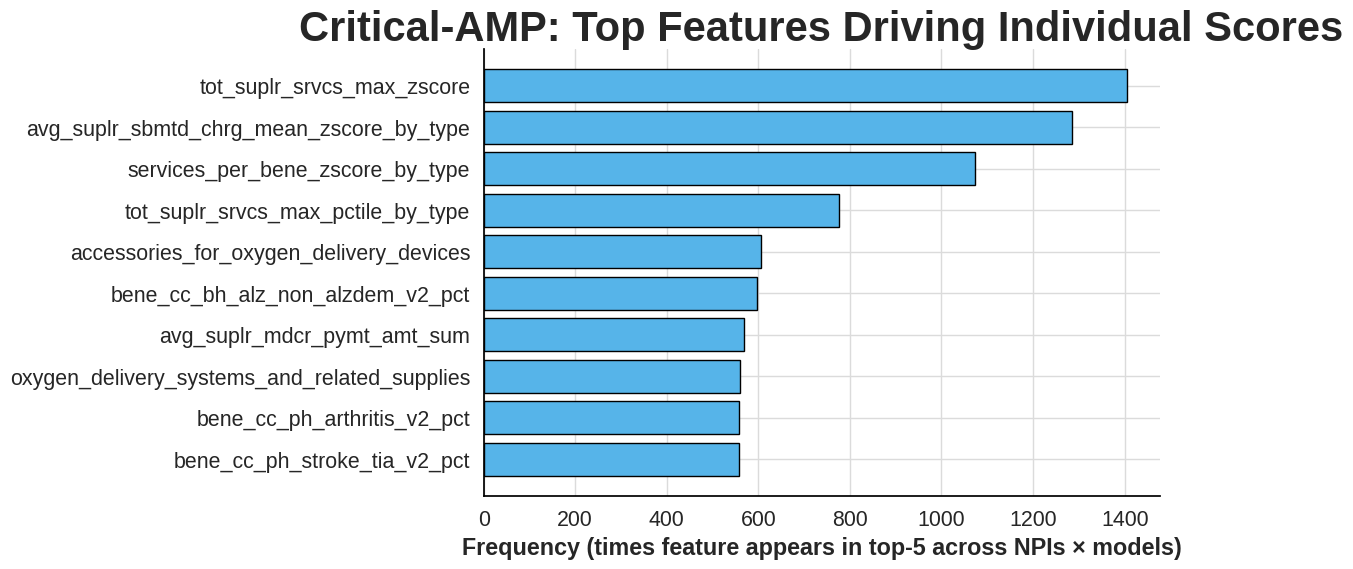

In [61]:
plot_feature_summary(
    cat_label='Critical-AMP',
    source_labels=['Critical-AMP']
)


Critical-MO — Top Features Driving Scores (129 NPIs):
Feature                                   Frequency  Avg Contrib
----------------------------------------------------------------------
avg_suplr_sbmtd_chrg_mean_zscore_by_type        152       0.6386
tot_suplr_srvcs_max_zscore                      145       0.2388
services_per_bene_zscore_by_type                133       0.6528
bene_cc_ph_arthritis_v2_pct                      78       0.6309
tot_suplr_srvcs_max_pctile_by_type               74       0.2720
bene_cc_ph_stroke_tia_v2_pct                     63       0.0327
avg_suplr_mdcr_pymt_amt_sum                      61       0.6054
bene_cc_bh_alz_non_alzdem_v2_pct                 61       0.5021
form_count_cash_or_cash_equivalent               58       1.2087
claims_per_bene_zscore_by_type                   57       1.2421
bene_dual_cnt                                    56       1.1701
accessories_for_oxygen_delivery_devices          47       2.2703
total_payment_pctile_by_type 

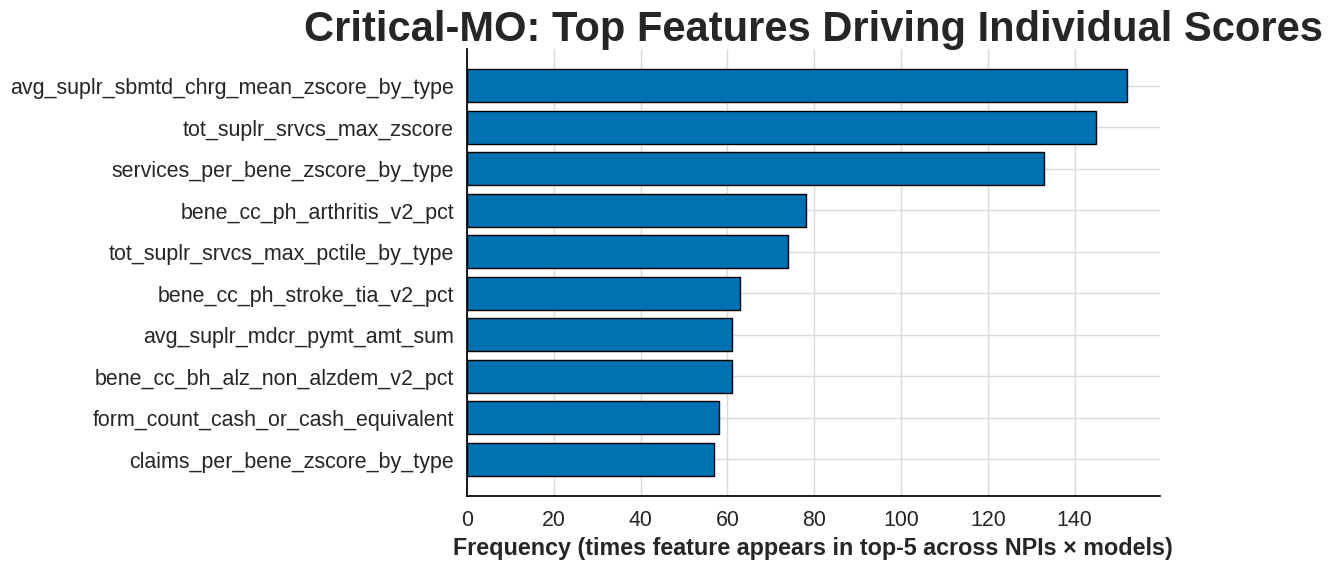

In [62]:
plot_feature_summary(
    cat_label='Critical-MO',
    source_labels=['Critical-MO']
)


MO + Active Medicaid Providers — Top Features Driving Scores (1,306 NPIs):
Feature                                   Frequency  Avg Contrib
----------------------------------------------------------------------
tot_suplr_srvcs_max_zscore                     1551       0.2522
avg_suplr_sbmtd_chrg_mean_zscore_by_type       1438       0.5502
services_per_bene_zscore_by_type               1206       0.3918
tot_suplr_srvcs_max_pctile_by_type              850       0.3287
bene_cc_bh_alz_non_alzdem_v2_pct                658       0.5046
accessories_for_oxygen_delivery_devices         653       2.3046
bene_cc_ph_arthritis_v2_pct                     636       0.3671
avg_suplr_mdcr_pymt_amt_sum                     630       0.5313
bene_cc_ph_stroke_tia_v2_pct                    620       0.2269
oxygen_delivery_systems_and_related_supplies        597       3.0417
claims_per_bene_zscore_by_type                  558       1.5320
bene_dual_cnt                                   537       0.5939
form

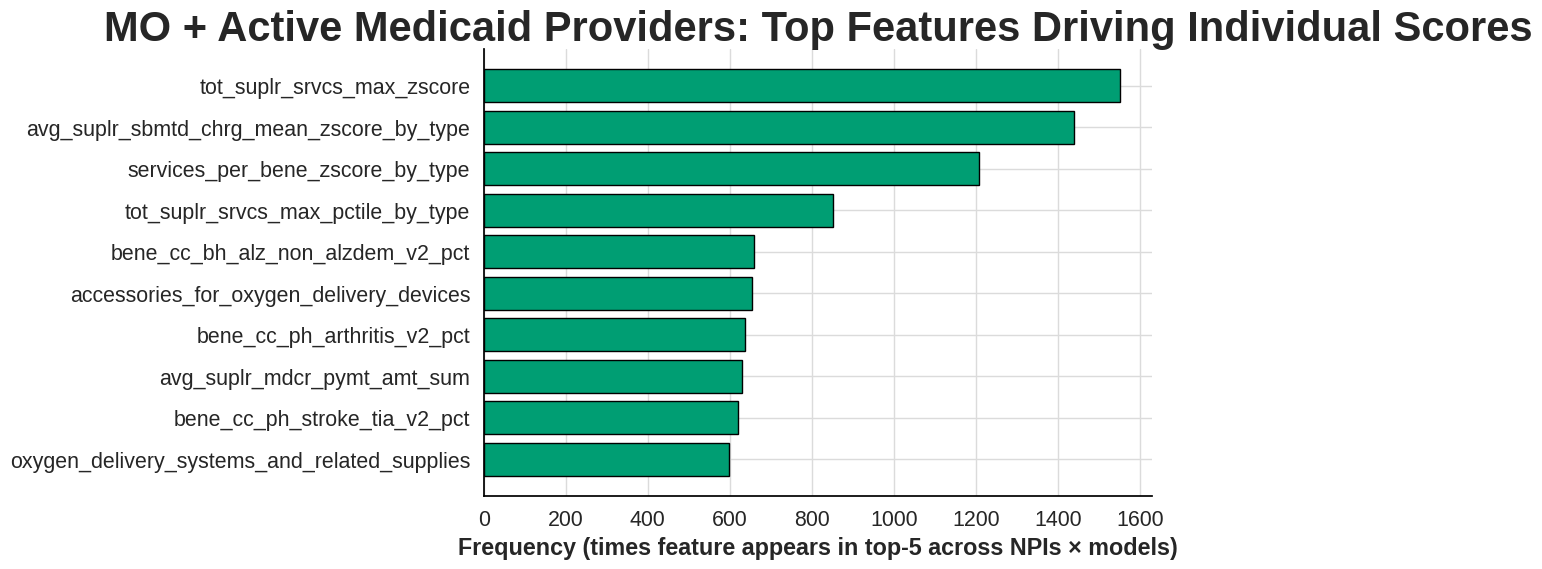

In [63]:
plot_feature_summary(
    cat_label='MO + Active Medicaid Providers',
    source_labels=['Critical-MO', 'Critical-AMP'] 
)

## Create Final Scored Dataset

In [22]:
output_df = pd.DataFrame()

for col in identifiers.columns:
    output_df[col] = identifiers[col].values
if provider_state is not None:
    output_df['rfrg_prvdr_state_abrvtn'] = provider_state
if active_medicaid is not None:
    output_df['active_medicaid_provider_flag'] = active_medicaid

output_df['original_index'] = df.index
output_df['risk_score'] = risk_scores
output_df['is_anomaly'] = is_anomaly
output_df['percentile_rank'] = stats.rankdata(risk_scores) / len(risk_scores) * 100
output_df['risk_category'] = risk_category

for model_name in z_scores.keys():
    output_df[f'{model_name}_raw_score'] = raw_scores[model_name]
    output_df[f'{model_name}_zscore'] = z_scores[model_name]
output_df['aggregated_zscore'] = aggregated_z

total_weight = sum(MODEL_WEIGHTS.values())
for model_name in z_scores.keys():
    output_df[f'{model_name}_weighted_contrib'] = (
        z_scores[model_name] * MODEL_WEIGHTS[model_name] / total_weight)

# Add per-instance features (Critical-AMP & Critical-MO only)
if len(per_instance_features_all) > 0:
    for col in per_instance_features_all.columns:
        output_df[col] = np.nan
        output_df.loc[per_instance_features_all.index, col] = per_instance_features_all[col].values

if 'target' in df.columns:
    output_df['target'] = df['target'].values

output_df = output_df.sort_values('risk_score', ascending=False)

print(f"Output DataFrame: {output_df.shape}")
print(f"\nRisk category distribution:")
print(output_df['risk_category'].value_counts().to_string())


Output DataFrame: (140827, 49)

Risk category distribution:
risk_category
Medium          74613
Low             36075
High            23097
Critical         5736
Critical-AMP     1177
Critical-MO       129


In [25]:
# Display top anomalies
print('\nTop 20 Highest Risk Records:')
display_cols = ['npi',  'risk_score', 'percentile_rank', 'risk_category', 'is_anomaly']
if 'rfrg_prvdr_state_abrvtn' in output_df.columns:
    display_cols.insert(2, 'rfrg_prvdr_state_abrvtn')
if 'active_medicaid_provider_flag' in output_df.columns:
    display_cols.insert(3, 'active_medicaid_provider_flag')
for model_name in z_scores.keys():
    display_cols.append(f'{model_name}_zscore')
print(output_df[[c for c in display_cols if c in output_df.columns]].head(20).to_string())

# Show per-instance features for Critical sub-categories
feat_display_cols = ['npi', 'risk_score', 'risk_category']
for model_name in models.keys():
    feat_display_cols.extend([
        f'{model_name}_top1_feature', f'{model_name}_top1_contribution',
        f'{model_name}_top2_feature', f'{model_name}_top2_contribution'])

for cat_label in ['Critical-AMP', 'Critical-MO']:
    cat_df = output_df[output_df['risk_category'] == cat_label]
    if len(cat_df) > 0:
        print(f"\n\n{cat_label} PROVIDERS — Per-Instance Top Features ({len(cat_df):,} total):")
        print('=' * 120)
        print(cat_df[feat_display_cols].head(15).to_string())



Top 20 Highest Risk Records:
               npi  risk_score rfrg_prvdr_state_abrvtn  active_medicaid_provider_flag  percentile_rank risk_category  is_anomaly  isolation_forest_zscore  inne_zscore  ecod_zscore
131005  1922666890       100.0                      IL                              0        99.952424      Critical           1                      4.0     1.747553          4.0
31711   1225126808       100.0                      IL                              0        99.952424      Critical           1                      4.0     1.747553          4.0
128215  1912018599       100.0                      IL                              0        99.952424      Critical           1                      4.0     1.747553          4.0
101875  1720078843       100.0                      MO                              1        99.952424  Critical-AMP           1                      4.0     1.747553          4.0
47230   1336179126       100.0                      OK                

## Critical-AMP & Critical-MO Risk Profiles

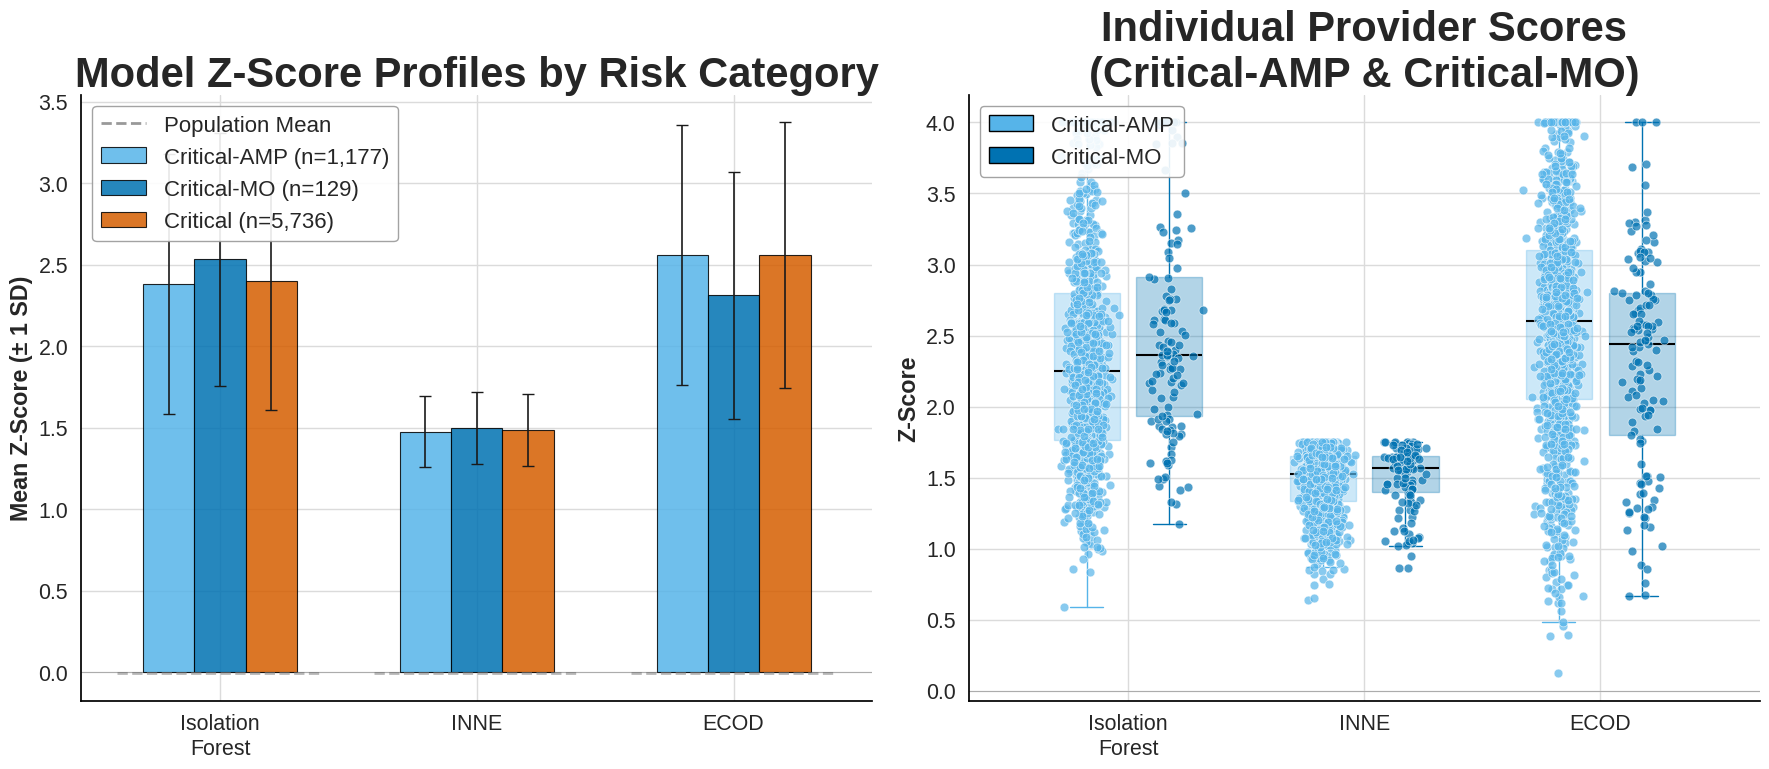


RISK PROFILE SUMMARY

Critical-AMP (n=1,177):
  isolation_forest      mean z=+2.38  median=+2.25  max=+4.00
  inne                  mean z=+1.48  median=+1.52  max=+1.75
  ecod                  mean z=+2.56  median=+2.60  max=+4.00

Critical-MO (n=129):
  isolation_forest      mean z=+2.53  median=+2.37  max=+4.00
  inne                  mean z=+1.50  median=+1.57  max=+1.75
  ecod                  mean z=+2.31  median=+2.44  max=+4.00

Critical (n=5,736):
  isolation_forest      mean z=+2.40  median=+2.26  max=+4.00
  inne                  mean z=+1.49  median=+1.55  max=+1.75
  ecod                  mean z=+2.56  median=+2.55  max=+4.00


In [26]:
from matplotlib.patches import Patch

cat_colors = {
    'Critical-AMP': '#56B4E9', 'Critical-MO': '#0072B2',
    'Critical': '#D55E00', 'Population': '#999999',
}
model_names_ordered = list(models.keys())
model_labels = {'isolation_forest': 'Isolation\nForest', 'inne': 'INNE', 'ecod': 'ECOD'}

# Build comparison data
comparison_rows = []
for idx, row in output_df.iterrows():
    for m in model_names_ordered:
        comparison_rows.append({'category': row['risk_category'], 'model': m,
                                'zscore': row[f'{m}_zscore']})
comp_df = pd.DataFrame(comparison_rows)

categories_to_show = ['Critical-AMP', 'Critical-MO', 'Critical']
pop_means = comp_df.groupby('model')['zscore'].mean().to_dict()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Grouped bar chart of mean z-scores
bar_width = 0.2
x_positions = np.arange(len(model_names_ordered))
cats_present = [c for c in categories_to_show if c in output_df['risk_category'].values]

for i, cat in enumerate(cats_present):
    cat_data = comp_df[comp_df['category'] == cat]
    means = [cat_data[cat_data['model'] == m]['zscore'].mean() for m in model_names_ordered]
    stds = [cat_data[cat_data['model'] == m]['zscore'].std() for m in model_names_ordered]
    offset = (i - len(cats_present)/2 + 0.5) * bar_width
    axes[0].bar(x_positions + offset, means, bar_width, yerr=stds, capsize=4,
               color=cat_colors[cat], edgecolor='black', linewidth=0.8,
               label=f'{cat} (n={(output_df["risk_category"]==cat).sum():,})',
               alpha=0.85, error_kw={'linewidth': 1.2})

for j, m in enumerate(model_names_ordered):
    axes[0].hlines(pop_means[m], j-0.4, j+0.4, colors='#999999', linewidth=2, linestyle='--', alpha=0.7)
axes[0].plot([], [], color='#999999', linewidth=2, linestyle='--', label='Population Mean')

axes[0].set_xticks(x_positions)
axes[0].set_xticklabels([model_labels.get(m, m) for m in model_names_ordered])
axes[0].set_ylabel('Mean Z-Score (± 1 SD)')
axes[0].set_title('Model Z-Score Profiles by Risk Category')
axes[0].axhline(y=0, color='black', linewidth=0.5, alpha=0.3)
add_legend(axes[0], fontsize=FONT_SIZE_LEGEND-4, loc='upper left')

# Right: Strip + Box plot
critical_cats = [c for c in ['Critical-AMP', 'Critical-MO'] if c in output_df['risk_category'].values]
if critical_cats:
    crit_df = output_df[output_df['risk_category'].isin(critical_cats)]
    plot_data = []
    for _, row in crit_df.iterrows():
        for m in model_names_ordered:
            plot_data.append({'category': row['risk_category'],
                              'model': model_labels.get(m, m), 'zscore': row[f'{m}_zscore']})
    plot_df = pd.DataFrame(plot_data)
    model_label_order = [model_labels.get(m, m) for m in model_names_ordered]

    for ci, cat in enumerate(critical_cats):
        cat_subset = plot_df[plot_df['category'] == cat]
        positions = np.arange(len(model_label_order)) + (ci - 0.5) * 0.35
        bp_data = [cat_subset[cat_subset['model'] == ml]['zscore'].values for ml in model_label_order]
        axes[1].boxplot(bp_data, positions=positions, widths=0.28, patch_artist=True, showfliers=False,
                        boxprops=dict(facecolor=cat_colors[cat], alpha=0.3, edgecolor=cat_colors[cat]),
                        medianprops=dict(color='black', linewidth=1.5),
                        whiskerprops=dict(color=cat_colors[cat]),
                        capprops=dict(color=cat_colors[cat]))
        for j, ml in enumerate(model_label_order):
            vals = cat_subset[cat_subset['model'] == ml]['zscore'].values
            jitter = np.random.normal(0, 0.04, size=len(vals))
            axes[1].scatter(positions[j] + jitter, vals, color=cat_colors[cat],
                            edgecolor='white', linewidth=0.5, s=40, alpha=0.7, zorder=5)

    axes[1].set_xticks(np.arange(len(model_label_order)))
    axes[1].set_xticklabels(model_label_order)
    axes[1].set_ylabel('Z-Score')
    axes[1].set_title('Individual Provider Scores\n(Critical-AMP & Critical-MO)')
    axes[1].axhline(y=0, color='black', linewidth=0.5, alpha=0.3)
    legend_patches = [Patch(facecolor=cat_colors[c], edgecolor='black', label=c) for c in critical_cats]
    axes[1].legend(handles=legend_patches, fontsize=FONT_SIZE_LEGEND-4, loc='upper left', framealpha=0.9)

finalize(fig)
plt.savefig(f'{OUTPUT_DIR}/investigator_risk_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

# Print stats
print('\nRISK PROFILE SUMMARY')
print('=' * 70)
for cat in cats_present:
    cat_df_tmp = output_df[output_df['risk_category'] == cat]
    print(f"\n{cat} (n={len(cat_df_tmp):,}):")
    for m in model_names_ordered:
        vals = cat_df_tmp[f'{m}_zscore']
        print(f"  {m:20s}  mean z={vals.mean():+.2f}  median={vals.median():+.2f}  max={vals.max():+.2f}")


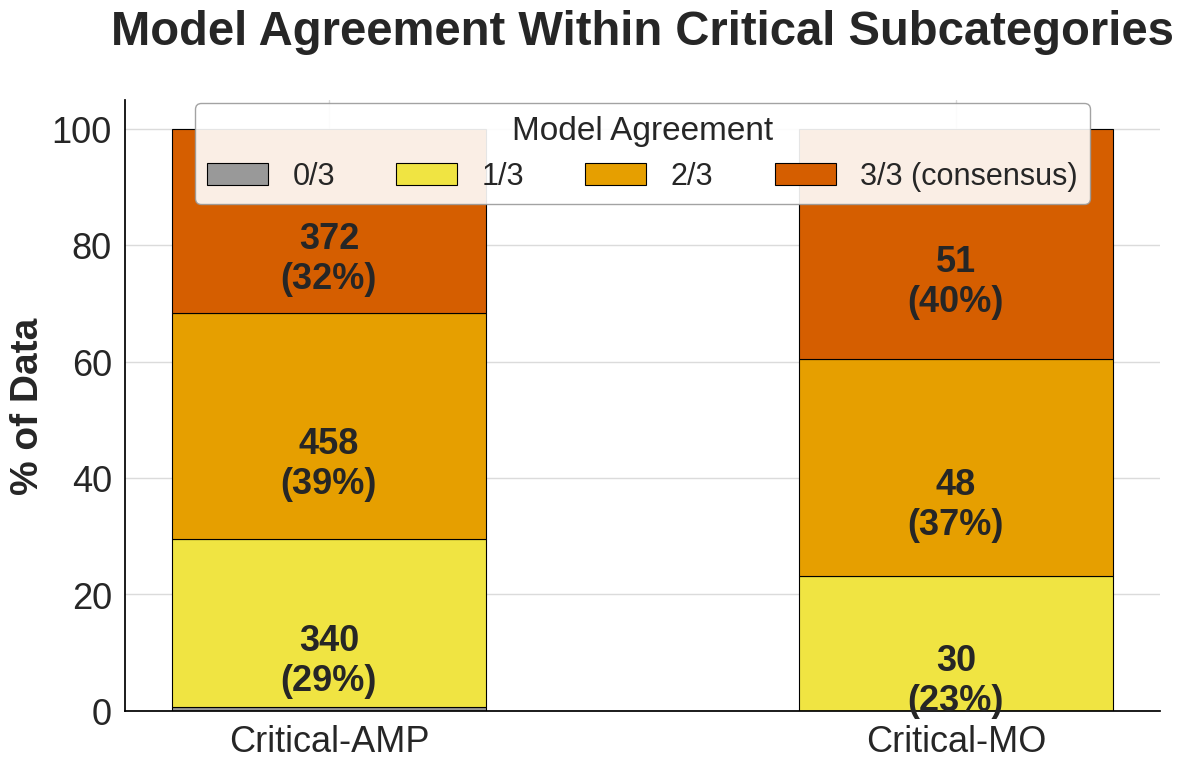


Critical-AMP — MODEL AGREEMENT BREAKDOWN
  0/3 models agree:      7 providers (  0.6%)  mean score: 69.1
    Flagging breakdown: isolation_forest: 0, inne: 0, ecod: 0
  1/3 models agree:    340 providers ( 28.9%)  mean score: 72.0
    Flagging breakdown: isolation_forest: 97, inne: 10, ecod: 233
  2/3 models agree:    458 providers ( 38.9%)  mean score: 77.1
    Flagging breakdown: isolation_forest: 428, inne: 185, ecod: 303
  3/3 models agree:    372 providers ( 31.6%)  mean score: 86.8
    Flagging breakdown: isolation_forest: 372, inne: 372, ecod: 372


Critical-MO — MODEL AGREEMENT BREAKDOWN
  1/3 models agree:     30 providers ( 23.3%)  mean score: 71.2
    Flagging breakdown: isolation_forest: 15, inne: 0, ecod: 15
  2/3 models agree:     48 providers ( 37.2%)  mean score: 74.7
    Flagging breakdown: isolation_forest: 46, inne: 27, ecod: 23
  3/3 models agree:     51 providers ( 39.5%)  mean score: 85.5
    Flagging breakdown: isolation_forest: 51, inne: 51, ecod: 51


KNOWN FR

In [54]:
# ============================================================================
# CRITICAL-AMP & CRITICAL-MO: MODEL AGREEMENT TRIAGE
# ============================================================================

from matplotlib.patches import Patch

# Align model flags to output_df using the original index (survives the sort)
output_df['n_models_flagged'] = contribution_df.loc[output_df['original_index'], 'n_models_flagged'].values
for m in model_names:
    output_df[f'{m}_flag'] = contribution_df.loc[output_df['original_index'], f'{m}_flag'].values

agreement_colors = {0: '#999999', 1: '#F0E442', 2: '#E69F00', 3: '#D55E00'}
agreement_labels = {0: '0/3', 1: '1/3', 2: '2/3', 3: '3/3 (consensus)'}

fig, ax_bar = plt.subplots(figsize=(12, 8))

# ── Stacked proportion bars for each Critical subcategory ──────────────────
cat_labels = ['Critical-AMP', 'Critical-MO']
bar_x = np.arange(len(cat_labels))
bar_width = 0.5
bottoms = np.zeros(len(cat_labels))

for n_flag in [0, 1, 2, 3]:
    proportions = []
    counts = []

    for cat_label in cat_labels:
        cat_df = output_df[output_df['risk_category'] == cat_label]  # filter dataframe by category
        n_in_tier = (cat_df['n_models_flagged'] == n_flag).sum()  # count providers in agreement tier
        counts.append(n_in_tier)  # store raw count
        proportions.append(n_in_tier / len(cat_df) * 100 if len(cat_df) > 0 else 0)  # compute percent

    proportions = np.array(proportions)  # convert list to numpy array

    bars = ax_bar.bar(  # create stacked bar segment
        bar_x,
        proportions,
        bar_width,
        bottom=bottoms,
        color=agreement_colors[n_flag],
        edgecolor='black',
        linewidth=0.8,
        label=agreement_labels[n_flag]
    )

    for i, (p, c) in enumerate(zip(proportions, counts)):
        if p > 4:
            ax_bar.text(  # annotate bar segment with count and percent
                bar_x[i],
                bottoms[i] + p / 2,
                f'{c:,}\n({p:.0f}%)',
                ha='center',
                va='top',
                fontsize=26,
                fontweight='bold'
            )

    bottoms += proportions  # update stacking baseline

# ── Axis formatting ───────────────────────────────────────────────────────
ax_bar.set_xticks(bar_x)  # set x tick positions
ax_bar.set_xticklabels(cat_labels)  # set x tick labels
ax_bar.tick_params(axis='x', labelsize=26)  # enlarge x-axis tick labels
ax_bar.tick_params(axis='y', labelsize=26)  # enlarge y-axis tick labels

ax_bar.set_ylabel('% of Data', fontsize=28)  # enlarge y-axis label
ax_bar.set_title(
    'Model Agreement Within Critical Subcategories',
    fontsize=34,
    pad=40
)  # enlarge and space title

ax_bar.set_ylim(0, 105)  # set y-axis limit

# ── Legend centered under title ───────────────────────────────────────────
ax_bar.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    frameon=True,
    fontsize=22,
    title='Model Agreement',  # add legend title
    title_fontsize=24  # control title size independently
)

finalize(fig)
# plt.savefig(f'{OUTPUT_DIR}/critical_model_agreement_triage.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Breakdown tables ──────────────────────────────────────────────────────
for cat_label in ['Critical-AMP', 'Critical-MO']:
    cat_df = output_df[output_df['risk_category'] == cat_label]
    if len(cat_df) == 0:
        continue
    print(f'\n{cat_label} — MODEL AGREEMENT BREAKDOWN')
    print('=' * 70)
    for n in sorted(cat_df['n_models_flagged'].unique()):
        subset = cat_df[cat_df['n_models_flagged'] == n]
        pct = len(subset) / len(cat_df) * 100
        mean_score = subset['risk_score'].mean()
        flag_detail = []
        for m in model_names:
            n_flagged_by_m = subset[f'{m}_flag'].sum()
            flag_detail.append(f'{m}: {n_flagged_by_m}')
        print(f'  {n}/3 models agree: {len(subset):>6,} providers ({pct:5.1f}%)  '
              f'mean score: {mean_score:.1f}')
        print(f'    Flagging breakdown: {", ".join(flag_detail)}')
    print()

# ── Check known fraud (target=1) by agreement level ──────────────────────
if 'target' in output_df.columns and output_df['target'].sum() > 0:
    print('\n' + '=' * 70)
    print('KNOWN FRAUD (target=1) BY MODEL AGREEMENT LEVEL')
    print('=' * 70)

    for cat_label in ['Critical-AMP', 'Critical-MO']:
        cat_df = output_df[output_df['risk_category'] == cat_label]
        if len(cat_df) == 0:
            continue
        cat_fraud = cat_df[cat_df['target'] == 1]
        print(f'\n{cat_label}: {len(cat_fraud):,} known fraud out of {len(cat_df):,} total')
        print('-' * 70)
        for n in [1, 2, 3]:
            n_agree = cat_df[cat_df['n_models_flagged'] == n]
            n_agree_fraud = n_agree[n_agree['target'] == 1]
            pct_of_tier = len(n_agree_fraud) / len(n_agree) * 100 if len(n_agree) > 0 else 0
            print(f'  {n}/3 models: {len(n_agree_fraud):>4} fraud / {len(n_agree):>6} total '
                  f'({pct_of_tier:.2f}% hit rate)')

    print(f'\n{"─" * 70}')
    print('ALL PROVIDERS — Known Fraud by Agreement Level')
    print('─' * 70)
    for n in [0, 1, 2, 3]:
        n_agree = output_df[output_df['n_models_flagged'] == n]
        n_agree_fraud = n_agree[n_agree['target'] == 1]
        pct = len(n_agree_fraud) / len(n_agree) * 100 if len(n_agree) > 0 else 0
        marker = ' <<<' if n == 3 else ''
        print(f'  {n}/3 models: {len(n_agree_fraud):>4} fraud / {len(n_agree):>6,} total '
              f'({pct:.2f}% hit rate){marker}')

    total_fraud = output_df['target'].sum()
    consensus_fraud = output_df[(output_df['n_models_flagged'] == 3) & (output_df['target'] == 1)]
    print(f'\n  Consensus (3/3) captures {len(consensus_fraud)}/{int(total_fraud)} '
          f'known fraud cases ({len(consensus_fraud)/total_fraud*100:.1f}% recall)')
    two_plus_fraud = output_df[(output_df['n_models_flagged'] >= 2) & (output_df['target'] == 1)]
    print(f'  2+ models captures    {len(two_plus_fraud)}/{int(total_fraud)} '
          f'known fraud cases ({len(two_plus_fraud)/total_fraud*100:.1f}% recall)')
else:
    print('\nNo target column or no known fraud cases — skipping conviction overlap check.')

In [27]:
output_path = f'{OUTPUT_DIR}/ensemble_scored_dataset.csv'
output_df.to_csv(output_path, index=False)
print(f'Scored dataset exported to: {output_path}')
print(f'Total records: {len(output_df):,}')
print(f'Anomalies flagged: {output_df["is_anomaly"].sum():,} ({output_df["is_anomaly"].mean()*100:.2f}%)')


Scored dataset exported to: ensemble_outputs/ensemble_scored_dataset.csv
Total records: 140,827
Anomalies flagged: 7,042 (5.00%)


## Summary Statistics

In [28]:
print("ENSEMBLE ANOMALY DETECTION SUMMARY")
print("\nENSEMBLE CONFIGURATION:")
print(f"  Models: {list(models.keys())}")
print(f"  Weights: {MODEL_WEIGHTS}")
print(f"  Z-score Cap: {ZSCORE_CAP}")
print(f"  Contamination Rate: {FINAL_CONTAMINATION}")
print(f"\nDATASET:")
print(f"  Total Records: {len(df):,}")
print(f"  Features Used: {len(feature_cols)}")
print(f"\nRISK SCORE DISTRIBUTION:")
for cat in ['Low', 'Medium', 'High', 'Critical', 'Critical-AMP', 'Critical-MO']:
    count = (output_df['risk_category'] == cat).sum()
    pct = count / len(output_df) * 100
    if count > 0:
        print(f"  {cat}: {count:,} ({pct:.2f}%)")
print(f"\nANOMALY DETECTION:")
print(f"  Threshold (Risk Score): {threshold:.2f}")
print(f"  Anomalies Detected: {is_anomaly.sum():,}")
print(f"  Normal Records: {(is_anomaly == 0).sum():,}")
print(f"\nPER-INSTANCE EXPLAINABILITY:")
n_amp = (output_df['risk_category'] == 'Critical-AMP').sum()
n_mo = (output_df['risk_category'] == 'Critical-MO').sum()
print(f"  Critical-AMP: {n_amp:,}")
print(f"  Critical-MO:  {n_mo:,}")
print(f"  Total with per-instance features: {n_amp + n_mo:,}")
print(f"\nMODEL AGREEMENT:")
for m1 in z_scores.keys():
    for m2 in z_scores.keys():
        if m1 < m2:
            corr = np.corrcoef(z_scores[m1], z_scores[m2])[0, 1]
            print(f"  {m1} vs {m2}: {corr:.3f}")


ENSEMBLE ANOMALY DETECTION SUMMARY

ENSEMBLE CONFIGURATION:
  Models: ['isolation_forest', 'inne', 'ecod']
  Weights: {'isolation_forest': 1.0, 'inne': 1.0, 'ecod': 1.0}
  Z-score Cap: 4.0
  Contamination Rate: 0.05

DATASET:
  Total Records: 140,827
  Features Used: 63

RISK SCORE DISTRIBUTION:
  Low: 36,075 (25.62%)
  Medium: 74,613 (52.98%)
  High: 23,097 (16.40%)
  Critical: 5,736 (4.07%)
  Critical-AMP: 1,177 (0.84%)
  Critical-MO: 129 (0.09%)

ANOMALY DETECTION:
  Threshold (Risk Score): 68.37
  Anomalies Detected: 7,042
  Normal Records: 133,785

PER-INSTANCE EXPLAINABILITY:
  Critical-AMP: 1,177
  Critical-MO:  129
  Total with per-instance features: 1,306

MODEL AGREEMENT:
  inne vs isolation_forest: 0.724
  ecod vs isolation_forest: 0.805
  ecod vs inne: 0.620


## Validation Against Known Fraud Labels

In [30]:
validation_df = pd.DataFrame({
    'npi': df['npi'].values,
    'target': df['target'].values, 'risk_score': risk_scores,
    'is_anomaly': is_anomaly, 'aggregated_z': aggregated_z
})
for model_name in z_scores.keys():
    validation_df[f'{model_name}_zscore'] = z_scores[model_name]

known_fraud = validation_df[validation_df['target'] == 1]
known_normal = validation_df[validation_df['target'] == 0]
flagged = validation_df[validation_df['is_anomaly'] == 1]
flagged_fraud = known_fraud[known_fraud['is_anomaly'] == 1]

print("VALIDATION AGAINST KNOWN FRAUD LABELS")
print("=" * 60)
print(f"Total records:           {len(validation_df):,}")
print(f"Known fraud (target=1):  {len(known_fraud):,}")
print(f"Flagged as anomaly:      {len(flagged):,}")
print(f"Known fraud flagged:     {len(flagged_fraud):,} of {len(known_fraud):,}")
if len(known_fraud) > 0:
    print(f"Recall on known fraud:   {len(flagged_fraud)/len(known_fraud):.2%}")
if len(flagged) > 0:
    print(f"Precision:               {len(flagged_fraud)/len(flagged):.4%}")


VALIDATION AGAINST KNOWN FRAUD LABELS
Total records:           140,827
Known fraud (target=1):  56
Flagged as anomaly:      7,042
Known fraud flagged:     9 of 56
Recall on known fraud:   16.07%
Precision:               0.1278%


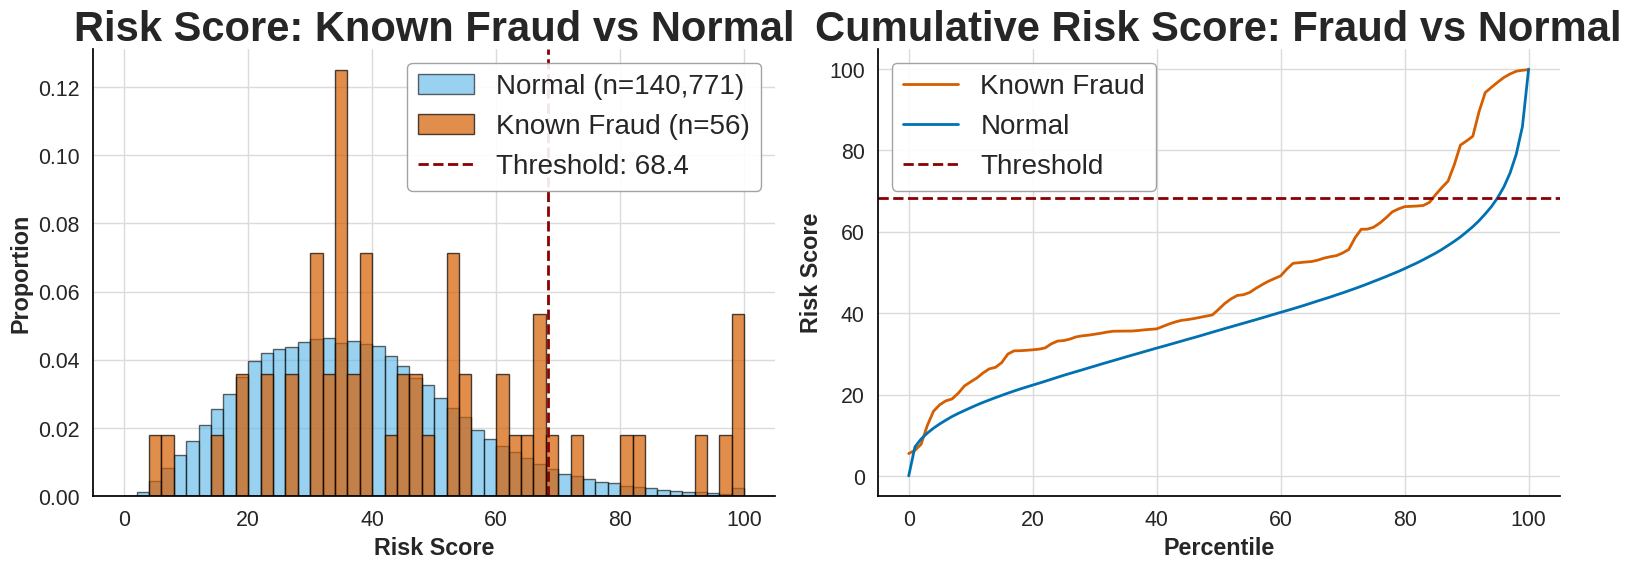

In [58]:
# Combine scores to create shared bin edges for both groups
all_scores = [known_normal['risk_score']]
# Add fraud scores when available so both groups share the same binning
if len(known_fraud) > 0:
    all_scores.append(known_fraud['risk_score'])

# Build a single array of all scores
all_scores = np.concatenate(all_scores)

# Create shared bin edges
bins = np.histogram_bin_edges(all_scores, bins=50)

# Create the figure and axes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot normal as per-bin proportion
axes[0].hist(
    known_normal['risk_score'],
    bins=bins,
    weights=np.ones(len(known_normal)) / len(known_normal),
    alpha=0.6,
    color='#56B4E9',
    edgecolor='black',
    label=f'Normal (n={len(known_normal):,})',
    density=False
)

# Plot fraud as per-bin proportion using the same bins
if len(known_fraud) > 0:
    axes[0].hist(
        known_fraud['risk_score'],
        bins=bins,
        weights=np.ones(len(known_fraud)) / len(known_fraud),
        alpha=0.7,
        color='#D55E00',
        edgecolor='black',
        label=f'Known Fraud (n={len(known_fraud):,})',
        density=False
    )

# Draw the threshold line
axes[0].axvline(
    x=threshold,
    color='darkred',
    linestyle='--',
    linewidth=2,
    label=f'Threshold: {threshold:.1f}'
)

# Set left plot labels and title
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Proportion')
axes[0].set_title('Risk Score: Known Fraud vs Normal')

# Add legend to left plot
add_legend(axes[0])

# Create the percentile grid
percentiles_check = np.arange(0, 101, 1)

# Plot fraud percentile curve when available
if len(known_fraud) > 0:
    axes[1].plot(
        percentiles_check,
        np.percentile(known_fraud['risk_score'], percentiles_check),
        color='#D55E00',
        linewidth=2,
        label='Known Fraud'
    )

# Plot normal percentile curve
axes[1].plot(
    percentiles_check,
    np.percentile(known_normal['risk_score'], percentiles_check),
    color='#0072B2',
    linewidth=2,
    label='Normal'
)

# Draw threshold line on percentile plot
axes[1].axhline(
    y=threshold,
    color='darkred',
    linestyle='--',
    linewidth=2,
    label='Threshold'
)

# Set right plot labels and title
axes[1].set_xlabel('Percentile')
axes[1].set_ylabel('Risk Score')
axes[1].set_title('Cumulative Risk Score: Fraud vs Normal')

# Add legend to right plot
add_legend(axes[1])

# Finalize and save the figure
finalize(fig)
plt.savefig(f'{OUTPUT_DIR}/fraud_validation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-Model Separation on Known Fraud Cases

PER-MODEL SEPARATION ON KNOWN FRAUD
Model                  Fraud Mean Z  Normal Mean Z   Separation      AUC
----------------------------------------------------------------------
isolation_forest             0.5798        -0.0044       0.5842   0.6111
inne                         0.3417        -0.0012       0.3429   0.6023
ecod                         0.6704        -0.0027       0.6730   0.6363
----------------------------------------------------------------------
ENSEMBLE                                                          0.6284


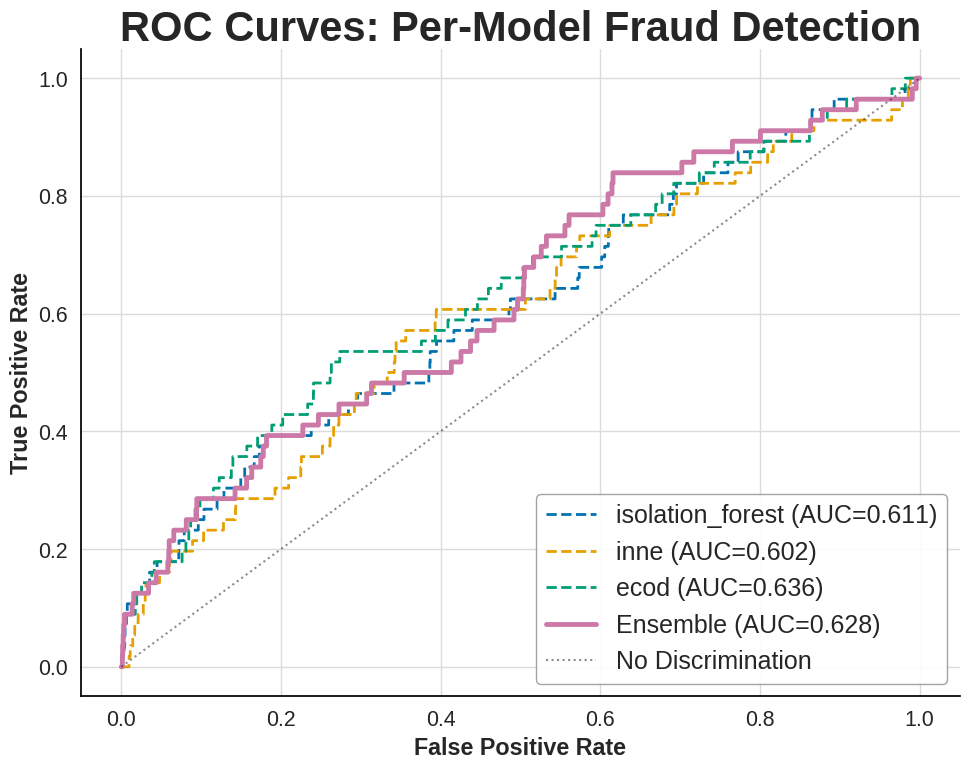

In [36]:
from sklearn.metrics import roc_auc_score, roc_curve

if len(known_fraud) >= 5:
    print('PER-MODEL SEPARATION ON KNOWN FRAUD')
    print('=' * 70)
    print(f"{'Model':<20} {'Fraud Mean Z':>14} {'Normal Mean Z':>14} {'Separation':>12} {'AUC':>8}")
    print('-' * 70)
    model_aucs = {}
    for model_name in z_scores.keys():
        col = f'{model_name}_zscore'
        fraud_z = validation_df[validation_df['target'] == 1][col]
        normal_z = validation_df[validation_df['target'] == 0][col]
        try:
            auc = roc_auc_score(validation_df['target'], validation_df[col])
        except ValueError:
            auc = float('nan')
        model_aucs[model_name] = auc
        print(f"{model_name:<20} {fraud_z.mean():>14.4f} {normal_z.mean():>14.4f} "
              f"{fraud_z.mean()-normal_z.mean():>12.4f} {auc:>8.4f}")
    try:
        ensemble_auc = roc_auc_score(validation_df['target'], validation_df['aggregated_z'])
    except ValueError:
        ensemble_auc = float('nan')
    print('-' * 70)
    print(f"{'ENSEMBLE':<20} {'':>14} {'':>14} {'':>12} {ensemble_auc:>8.4f}")
    print('=' * 70)

    # ROC curves
    fig, ax = plt.subplots(figsize=(10, 8))
    roc_colors = get_colors(len(model_names) + 1)
    for i, model_name in enumerate(model_names):
        col = f'{model_name}_zscore'
        fpr, tpr, _ = roc_curve(validation_df['target'], validation_df[col])
        ax.plot(fpr, tpr, label=f'{model_name} (AUC={model_aucs[model_name]:.3f})',
                color=roc_colors[i], linewidth=2, linestyle='--')
    fpr, tpr, _ = roc_curve(validation_df['target'], validation_df['aggregated_z'])
    ax.plot(fpr, tpr, label=f'Ensemble (AUC={ensemble_auc:.3f})',
            color=roc_colors[len(model_names)], linewidth=3.5)
    ax.plot([0,1], [0,1], 'k:', linewidth=1.5, alpha=0.5, label='No Discrimination')
    ax.set_title('ROC Curves: Per-Model Fraud Detection')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    add_legend(ax, fontsize=FONT_SIZE_LEGEND-2, loc='lower right')
    finalize(fig)
    plt.show()
else:
    print('Insufficient known fraud cases for per-model separation analysis.')


## NPI-Level Risk Aggregation

In [33]:
npi_risk = validation_df.groupby('npi').agg(
    mean_risk_score=('risk_score', 'mean'),
    max_risk_score=('risk_score', 'max'),
    n_years=('year', 'nunique'),
    years_flagged=('is_anomaly', 'sum'),
    max_aggregated_z=('aggregated_z', 'max'),
    target=('target', 'max')
).reset_index()

npi_risk['pct_years_flagged'] = npi_risk['years_flagged'] / npi_risk['n_years'] * 100
npi_risk = npi_risk.sort_values('max_risk_score', ascending=False)

print('NPI-LEVEL RISK AGGREGATION')
print('=' * 70)
print(f"Total unique NPIs:         {len(npi_risk):,}")
print(f"NPIs flagged in any year:  {(npi_risk['years_flagged'] > 0).sum():,}")
print(f"NPIs flagged in ALL years: {(npi_risk['pct_years_flagged'] == 100).sum():,}")
print()
print('Top 20 Highest Risk NPIs:')
print(npi_risk[['npi', 'max_risk_score', 'mean_risk_score', 'n_years',
                'years_flagged', 'pct_years_flagged', 'target']].head(20).to_string(index=False))

npi_output_path = f'{OUTPUT_DIR}/npi_level_risk_scores.csv'
npi_risk.to_csv(npi_output_path, index=False)
print(f'\nNPI-level scores exported to: {npi_output_path}')

if npi_risk['target'].sum() > 0:
    fraud_npis = npi_risk[npi_risk['target'] == 1]
    print(f'\nKnown Fraud NPIs: {len(fraud_npis):,}')
    print(f'  Mean max risk score: {fraud_npis["max_risk_score"].mean():.2f}')
    print(f'  Flagged in any year: {(fraud_npis["years_flagged"] > 0).sum():,}')


KeyError: "Column(s) ['year'] do not exist"

## Ensemble Stability Analysis

ENSEMBLE STABILITY ANALYSIS
Running 5 bootstrap resamples (top 5% = 7,041 records)...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.3s remaining:    1.0s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.6s finished


  Run 1: 3,091 unique NPIs


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.3s remaining:    0.9s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.6s finished


  Run 2: 3,196 unique NPIs


...

  Run 3: 3,115 unique NPIs


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.3s remaining:    1.0s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.6s finished


  Run 4: 3,081 unique NPIs


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.3s remaining:    0.9s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.6s finished


  Run 5: 3,201 unique NPIs

STABILITY RESULTS:
Mean pairwise Jaccard:    0.6381
Min:                      0.6288
Max:                      0.6450
NPIs flagged in ALL runs: 1,415
NPIs flagged in majority: 3,505


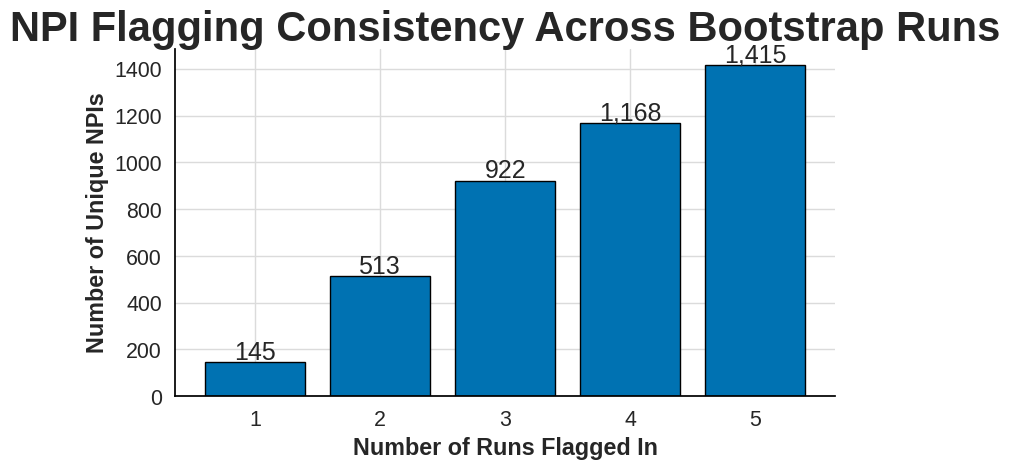

In [34]:
from itertools import combinations
from collections import Counter

def compute_jaccard(set1, set2):
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union > 0 else 0

N_STABILITY_RUNS = 5
TOP_K_PCT = 0.05
top_k = int(len(df) * TOP_K_PCT)

print(f'ENSEMBLE STABILITY ANALYSIS')
print(f'Running {N_STABILITY_RUNS} bootstrap resamples (top {TOP_K_PCT*100:.0f}% = {top_k:,} records)...')

flagged_npi_sets = []
for run in range(N_STABILITY_RUNS):
    np.random.seed(run * 42)
    boot_idx = np.random.choice(len(df), size=len(df), replace=True)
    X_boot = X.iloc[boot_idx]
    npi_boot = df['npi'].iloc[boot_idx].values
    boot_raw = {m: get_raw_scores(models[m], scalers[m], X_boot, m) for m in models}
    boot_z = {m: zscore_normalize(s, references[m]['train_mean'], references[m]['train_std'], cap=ZSCORE_CAP)
              for m, s in boot_raw.items()}
    boot_agg = aggregate_scores(boot_z, MODEL_WEIGHTS)
    top_indices = np.argsort(boot_agg)[-top_k:]
    flagged_npi_sets.append(set(npi_boot[top_indices]))
    print(f'  Run {run+1}: {len(flagged_npi_sets[-1]):,} unique NPIs')

similarities = [compute_jaccard(flagged_npi_sets[i], flagged_npi_sets[j])
                for i, j in combinations(range(N_STABILITY_RUNS), 2)]

npi_counts = Counter()
for s in flagged_npi_sets: npi_counts.update(s)
always_flagged = flagged_npi_sets[0]
for s in flagged_npi_sets[1:]: always_flagged = always_flagged & s
majority_flagged = {npi for npi, c in npi_counts.items() if c >= N_STABILITY_RUNS // 2 + 1}

print(f'\nSTABILITY RESULTS:')
print('=' * 60)
print(f'Mean pairwise Jaccard:    {np.mean(similarities):.4f}')
print(f'Min:                      {np.min(similarities):.4f}')
print(f'Max:                      {np.max(similarities):.4f}')
print(f'NPIs flagged in ALL runs: {len(always_flagged):,}')
print(f'NPIs flagged in majority: {len(majority_flagged):,}')

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
count_hist = [sum(1 for c in npi_counts.values() if c == r) for r in range(1, N_STABILITY_RUNS + 1)]
ax.bar(range(1, N_STABILITY_RUNS + 1), count_hist, color='#0072B2', edgecolor='black')
ax.set_xlabel('Number of Runs Flagged In')
ax.set_ylabel('Number of Unique NPIs')
ax.set_title('NPI Flagging Consistency Across Bootstrap Runs')
ax.set_xticks(range(1, N_STABILITY_RUNS + 1))
for i, v in enumerate(count_hist):
    ax.text(i + 1, v + max(count_hist)*0.01, f'{v:,}', ha='center', fontsize=FONT_SIZE_ANNOT-2)

finalize(fig)
plt.savefig(f'{OUTPUT_DIR}/ensemble_stability.png', dpi=150, bbox_inches='tight')
plt.show()
